In [1]:
from EXPERIMENT_HYPER_EMPIRICAL import *
from _FigureJiazeHelper import *
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
import matplotlib.colors as colors
from scipy.sparse.linalg import eigs, eigsh
from scipy.linalg import eig
from scipy.sparse import diags, csc_matrix
import hypergraphx as hgx
from _HyperCommunityDetection import *
from hypergraphx.viz import draw_communities
from hypergraphx.viz.draw_hypergraph import draw_hypergraph
import warnings
import pandas
from matplotlib.ticker import MaxNLocator
warnings.filterwarnings('ignore', category=FutureWarning)

%load_ext autoreload
%autoreload 2

In [2]:
# Matplotlib settings

# plt.style.use('seaborn-whitegrid')
plt.rc('figure', figsize=(8, 5))
plt.rc('font', size=16)
plt.rc('font', family='sans-serif')
plt.rcParams['font.sans-serif'] = 'verdana'
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.edgecolor'] = basic_line_color
plt.rcParams['xtick.color'] = basic_line_color
plt.rcParams['ytick.color'] = basic_line_color
plt.rcParams['axes.labelsize'] = 'large'
plt.rcParams['lines.markersize'] = 12

%config InlineBackend.figure_format = 'retina'

# CM

In [3]:
name = 'highschool'
ehg = EmpiricalHyperGraph(name)
givenNumGroup = 9
only_assortative = True
partition_path = f'./result/hyperEmpirical/{name}_BHPartition' \
                f'{f"_given{givenNumGroup}Groups" if givenNumGroup is not None else ""}' \
                f'{f"_assort" if only_assortative else ""}.pkl'
with open(partition_path, 'rb') as fr:
    BHpartition = pickle.load(fr)

meta = []
with open('./net_data/contact-high-school/highschool_data.pkl', 'rb') as fr:
    _data = pickle.load(fr)
    for i in range(_data['n']):
        meta.append(_data['meta'][i])
meta = np.array(meta)

givenNumGroup = 9
sign = False
partition_path = f'./result/hyperEmpirical/{name}_NBPartition' \
                f'{f"_given{givenNumGroup}Groups" if givenNumGroup is not None else ""}' \
                f'{f"_sign" if sign else "_noSign"}.pkl'
with open(partition_path, 'rb') as fr:
    NBpartition = pickle.load(fr)

Construct highschool hypergraph with 327 nodes, 7818 hyperedges and all possible k is [3, 4, 2, 5].


In [11]:
def visualMetaCM(partition, meta):
    partition_num = np.size(np.unique(partition))
    meta_num = np.size(np.unique(meta))
    cm = np.zeros((partition_num, meta_num))
    uniquePartition = np.unique(partition)
    uniqueMeta = np.unique(meta)
    for iP in uniquePartition:
        trueIndex = np.where(partition == iP)[0]
        for iM in uniqueMeta:
            i = np.where(uniquePartition == iP)
            j = np.where(uniqueMeta == iM)
            cm[j, i] = np.size(np.where(meta[trueIndex]==iM))
    df = pandas.DataFrame(cm, uniquePartition, uniqueMeta)
    return cm, df

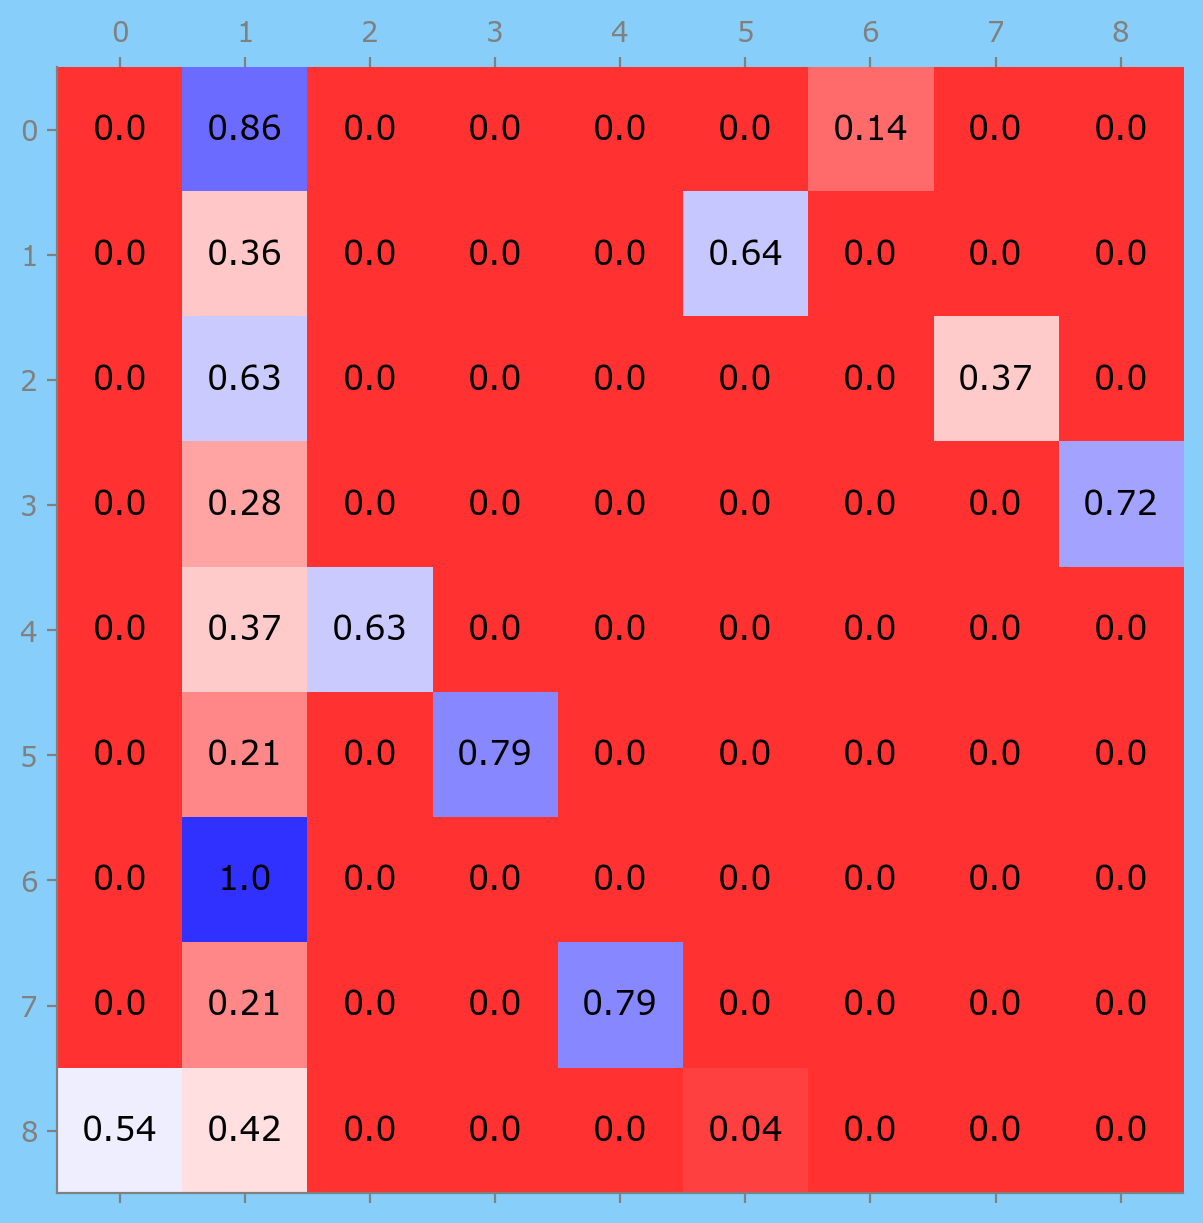

In [10]:
cm, df = visualMetaCM(BHpartition, NBpartition)
fig, ax = plt.subplots(figsize=(6, 6), facecolor='lightskyblue', layout='constrained')
plot_cm(cm, fig=fig, ax=ax)

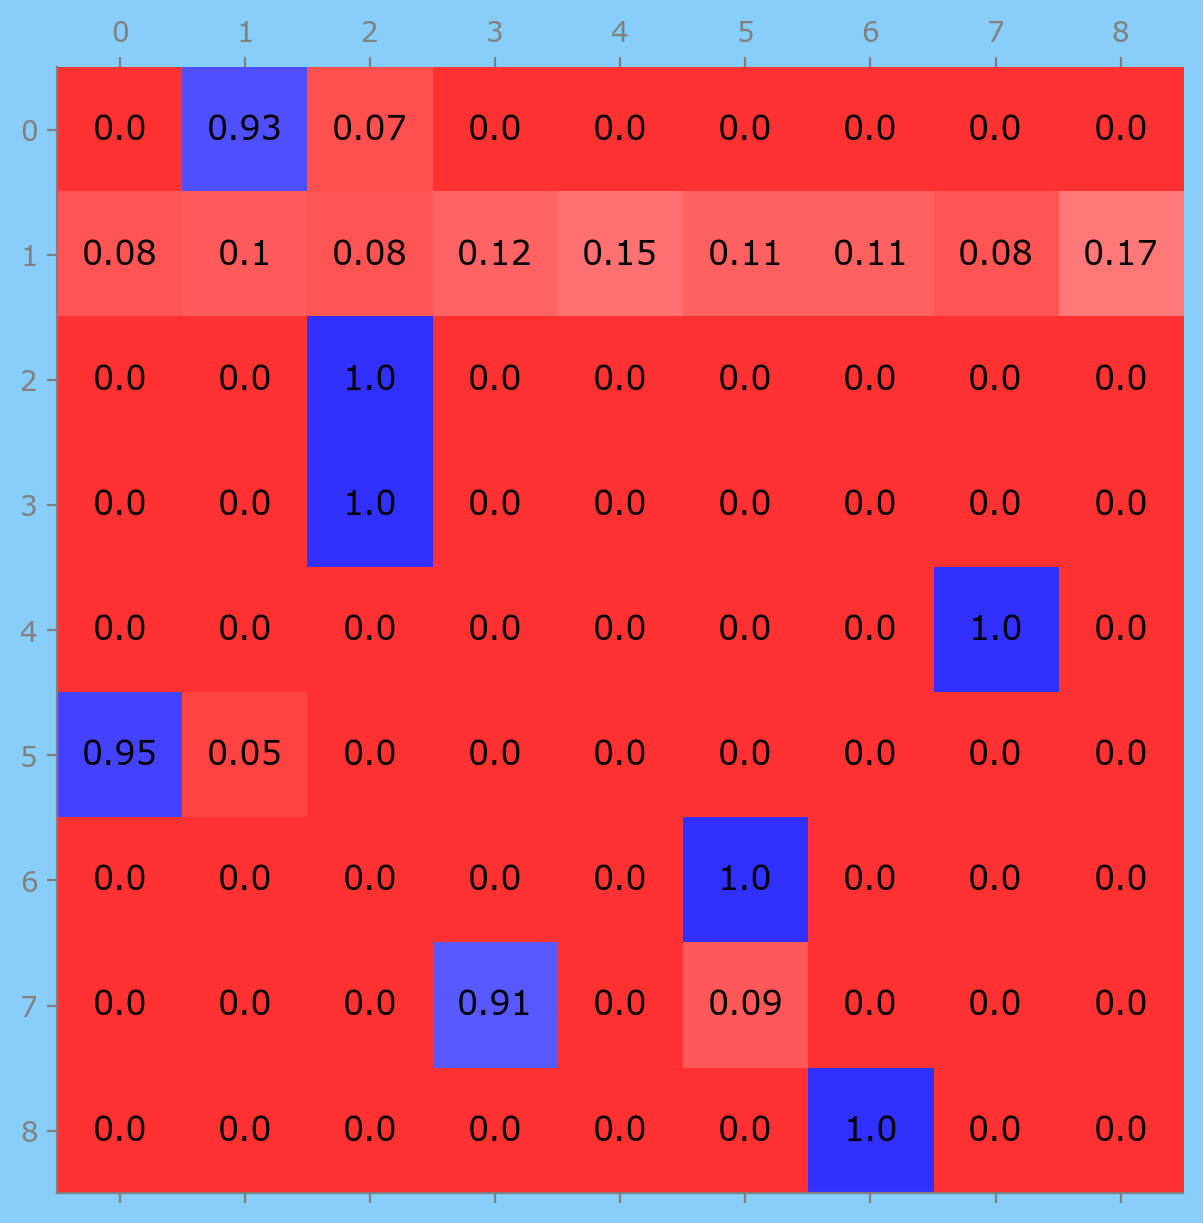

In [11]:
cm, df = visualMetaCM(NBpartition, meta)
fig, ax = plt.subplots(figsize=(6, 6), facecolor='lightskyblue', layout='constrained')
plot_cm(cm, fig=fig, ax=ax)

In [44]:
name = 'highschool'
givenNumGroup = 9
only_assortative = True
consider_ks = None
dc = True
partition_path = f'./result/hyperEmpirical/{name}_BHPartition' \
                f'{f"_given{givenNumGroup}Groups" if givenNumGroup is not None else ""}' \
                f'{f"_assort" if only_assortative else ""}' \
                f'{f"{consider_ks}" if consider_ks is not None else ""}' \
                f'{"_dc" if dc else ""}.pkl'
with open(partition_path, 'rb') as fr:
    partition = pickle.load(fr)
    cm, df = visualMetaCM(partition, meta)
    path = f'./result/hyperEmpirical/{name}_cm' \
        f'{f"_given{givenNumGroup}Groups" if givenNumGroup is not None else ""}' \
        f'{f"_assort" if only_assortative else ""}' \
        f'{f"{consider_ks}" if consider_ks is not None else ""}' \
        f'{"_dc" if dc else ""}.xlsx'
    with pandas.ExcelWriter(path) as writer:
        df.to_excel(excel_writer=writer)
        writer._save()

# Hedge Distributed in Detected Communities

Construct highschool hypergraph with 327 nodes, 7818 hyperedges and all possible k is [3, 4, 2, 5].
hyperedge:{2: 5498, 3: 2091, 4: 222, 5: 7}


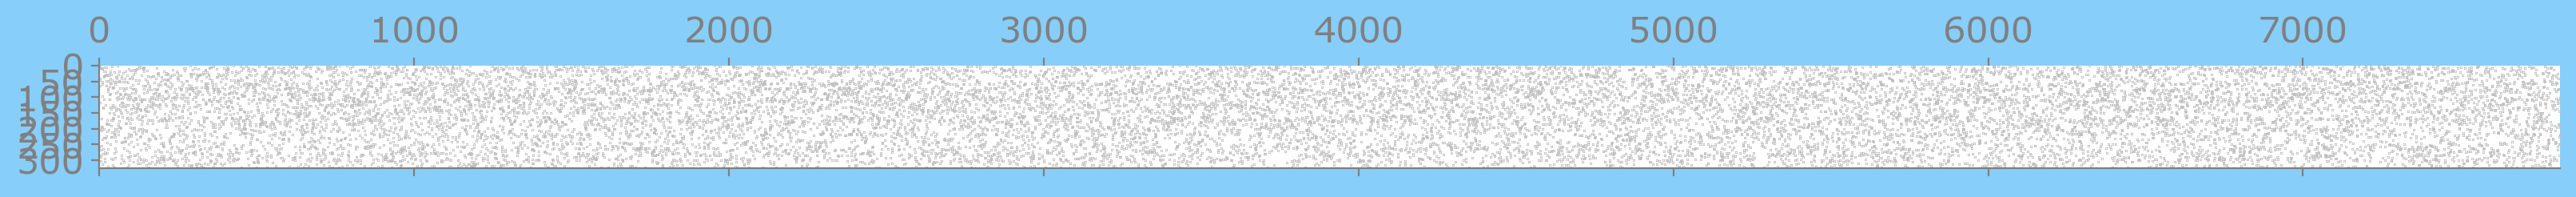

In [21]:
ehg = EmpiricalHyperGraph(name)
edge_order, edge_count = np.unique(ehg.H.sum(axis=0).flatten(), return_counts=True)
order_count = dict(zip(edge_order, edge_count))
print(f'hyperedge:{order_count}')
fig, ax = plt.subplots(figsize=(16, 8), facecolor='lightskyblue', layout='constrained')
H = ehg.H.toarray()
plt.spy(H, markersize=0.1, rasterized=True, color=gray)

In [5]:
def getDistributedHedgeinPartition(H, partition):
    recorded = dict()
    for ei in range(np.shape(H)[1]):
        order = np.sum(H[:, ei])
        hedge = np.where(H[:, ei]==1)[0]
        hedge_community = [partition[i] for i in hedge]
        hedge_community = " ".join([str(c) for c in sorted(hedge_community)])
        if hedge_community not in recorded.keys():
            recorded[hedge_community] = 1
        else:
            recorded[hedge_community] += 1
    return recorded

In [17]:
DisHedgeByMeta = getDistributedHedgeinPartition(H, meta)
DisHedgeByMeta = {k: v for k, v in sorted(DisHedgeByMeta.items(), key=lambda item: -item[1])}
for cc in list(DisHedgeByMeta.keys()):
    print(f'{cc}: {DisHedgeByMeta[cc]}')

PC PC: 651
2BIO3 2BIO3: 570
PC* PC*: 519
MP*2 MP*2: 467
MP MP: 396
2BIO1 2BIO1: 374
2BIO2 2BIO2: 367
2BIO3 2BIO3 2BIO3: 345
PSI* PSI*: 332
PC PC PC: 318
PC* PC* PC*: 217
MP*2 MP*2 MP*2: 207
MP*1 MP*1: 207
2BIO2 2BIO2 2BIO2: 163
MP MP MP: 162
PC PC*: 152
2BIO2 2BIO3: 152
2BIO1 2BIO1 2BIO1: 140
MP*1 MP*2: 119
MP MP*2: 117
2BIO1 2BIO3: 112
2BIO1 2BIO2: 106
PSI* PSI* PSI*: 87
MP MP*1: 87
PC PSI*: 65
MP*2 PSI*: 58
PC* PSI*: 56
MP*2 PC: 52
2BIO2 2BIO2 2BIO3: 49
PC PC PC PC: 43
2BIO3 MP*2: 42
2BIO2 PC*: 40
2BIO3 2BIO3 2BIO3 2BIO3: 38
MP PSI*: 37
2BIO3 PC: 31
MP*1 MP*1 MP*1: 30
2BIO1 2BIO1 2BIO2: 29
2BIO3 MP: 29
2BIO1 MP*2: 28
2BIO2 MP*2: 28
MP PC: 28
MP*1 PSI*: 26
MP*1 PC: 26
MP*1 MP*2 MP*2: 24
2BIO1 2BIO2 2BIO2: 24
2BIO3 PC*: 24
MP PC*: 23
2BIO1 2BIO1 2BIO1 2BIO1: 21
MP*2 PC*: 21
PC PC PC*: 20
2BIO1 PC*: 19
2BIO2 MP: 19
2BIO2 PSI*: 19
2BIO2 2BIO3 2BIO3: 19
PC* PC* PC* PC*: 18
MP MP MP*2: 18
2BIO1 2BIO1 2BIO3: 17
2BIO1 PC: 16
2BIO1 2BIO3 2BIO3: 16
PC PC* PC*: 16
2BIO3 PSI*: 16
MP MP*2 MP*2: 1

In [19]:
for cc in list(DisHedgeByMeta.keys()):
    if "MP*1" in cc or "MP*2" in cc:
        print(f'{cc}: {DisHedgeByMeta[cc]}')

MP*2 MP*2: 467
MP*2 MP*2 MP*2: 207
MP*1 MP*1: 207
MP*1 MP*2: 119
MP MP*2: 117
MP MP*1: 87
MP*2 PSI*: 58
MP*2 PC: 52
2BIO3 MP*2: 42
MP*1 MP*1 MP*1: 30
2BIO1 MP*2: 28
2BIO2 MP*2: 28
MP*1 PSI*: 26
MP*1 PC: 26
MP*1 MP*2 MP*2: 24
MP*2 PC*: 21
MP MP MP*2: 18
MP MP*2 MP*2: 15
MP*2 MP*2 MP*2 MP*2: 13
MP MP MP*1: 12
MP*1 PC*: 11
2BIO3 MP*2 MP*2: 11
MP*1 MP*1 MP*2: 9
MP MP*1 MP*1: 9
2BIO1 MP*1: 8
2BIO2 MP*1: 8
MP MP*1 MP*2: 6
MP MP MP MP*2: 6
2BIO3 MP*1: 6
MP*2 PSI* PSI*: 5
2BIO1 2BIO1 MP*2: 4
MP MP*2 PSI*: 4
MP MP*1 PSI*: 3
2BIO2 2BIO3 MP*2: 3
MP*2 MP*2 PC: 3
MP*1 PC PSI*: 3
MP*1 MP*1 MP*2 MP*2: 3
MP*1 MP*2 PSI*: 3
MP*2 MP*2 PSI*: 2
MP*2 PC PC: 2
MP*1 MP*2 MP*2 MP*2: 2
2BIO1 MP*2 PC*: 2
MP*1 MP*1 MP*1 MP*1: 2
2BIO3 2BIO3 MP*2: 2
MP*2 PC PSI*: 1
MP MP MP*2 MP*2: 1
MP MP*1 MP*2 MP*2: 1
MP MP*1 MP*1 MP*1: 1
MP MP*1 MP*1 MP*2: 1
2BIO3 2BIO3 MP*2 MP*2: 1
MP MP*2 PC PC: 1
MP MP MP MP*1: 1
MP*1 PSI* PSI*: 1
MP*1 MP*1 PSI*: 1
2BIO3 MP*1 MP*1: 1
2BIO3 MP*1 MP*2: 1
2BIO3 MP MP*2: 1
2BIO2 MP*1 PSI*: 1
MP 

In [6]:
DisHedgeByBH = getDistributedHedgeinPartition(H, BHpartition)
DisHedgeByBH = {k: v for k, v in sorted(DisHedgeByBH.items(), key=lambda item: -item[1])}
for cc in list(DisHedgeByBH.keys()):
    print(f'{cc}: {DisHedgeByBH[cc]}')

0 0: 868
3 3: 442
2 2: 365
1 1: 351
7 7: 346
0 3: 300
0 2: 283
3 3 3: 270
0 0 0: 256
8 8: 254
6 6: 235
0 7: 235
0 6: 186
7 7 7: 186
0 8: 180
2 2 2: 168
4 5: 158
4 4: 157
8 8 8: 149
4 4 4: 139
1 1 1: 135
0 4: 108
3 7: 102
1 8: 98
0 5: 91
5 5: 87
0 1: 81
5 5 5: 79
6 6 6: 78
4 8: 78
3 6: 56
0 0 2: 53
1 4: 48
5 8: 48
0 3 3: 46
3 3 3 3: 42
1 5: 41
4 4 5: 40
6 7: 38
0 7 7: 36
2 6: 33
1 1 8: 29
1 8 8: 29
2 3: 28
4 5 5: 27
0 2 2: 24
0 8 8: 22
0 0 0 0: 21
1 1 1 1: 21
1 7: 19
2 7: 19
4 8 8: 19
7 8: 19
0 0 4: 18
0 4 4: 18
3 3 7: 17
2 8: 16
4 4 4 4: 15
1 3: 15
2 4: 15
8 8 8 8: 15
7 7 7 7: 15
3 8: 14
0 5 5: 14
0 0 8: 13
0 6 6: 13
2 2 2 2: 13
0 0 3: 12
1 2: 12
0 1 1: 11
4 7: 11
5 8 8: 11
6 8: 11
1 6: 10
0 3 6: 10
0 0 6: 10
4 4 8: 10
5 7: 9
2 5: 9
2 2 6: 8
0 4 5: 8
3 7 7: 8
3 5: 8
0 4 8: 7
0 0 5: 7
5 5 5 5: 7
1 1 4: 7
3 6 6: 7
1 1 1 8: 6
1 5 5: 6
1 1 5: 6
5 6: 6
1 1 8 8: 6
6 6 6 6: 5
0 0 7: 5
0 2 2 2: 5
5 5 8: 5
1 8 8 8: 5
1 4 4: 4
0 5 8: 4
4 5 5 5: 4
4 6: 4
3 4: 4
2 6 6: 4
0 7 7 7: 3
2 4 4: 3
0 1 8:

In [32]:
uniuqe_hedgeMeta = list(DisHedgeByMeta.keys())
unique_hedgePartition = list(DisHedgeByBH.keys())
matrix = np.zeros((len(uniuqe_hedgeMeta), len(unique_hedgePartition)))
for ei in range(np.shape(H)[1]):
    order = np.sum(H[:, ei])
    hedge = np.where(H[:, ei]==1)[0]
    hedge_meta = [meta[i] for i in hedge]
    hedge_meta = " ".join([str(c) for c in sorted(hedge_meta)])
    hedge_community = [BHpartition[i] for i in hedge]
    hedge_community = " ".join([str(c) for c in sorted(hedge_community)])
    matrix[uniuqe_hedgeMeta.index(hedge_meta), unique_hedgePartition.index(hedge_community)] += 1
df = pandas.DataFrame(matrix, uniuqe_hedgeMeta, unique_hedgePartition)
save_path = f'./result/hyperEmpirical/{name}_hedge_distributed_meta_partition.xlsx'
with pandas.ExcelWriter(save_path) as writer:
    df.to_excel(excel_writer=writer)
    writer._save()

In [10]:
hedgeProb = dict()
for cc in list(DisHedgeByBH.keys()):
    _cc = [int(q) for q in cc.split(" ")]
    _, counts = np.unique(_cc, return_counts=True)
    counts = tuple(np.sort(counts))
    order = len(_cc)
    if order not in hedgeProb.keys():
        hedgeProb[order] = dict()
    if counts not in hedgeProb[order].keys():
        hedgeProb[order][counts] = DisHedgeByBH[cc]
    else:
        hedgeProb[order][counts] += DisHedgeByBH[cc]
# Print
for order in hedgeProb.keys():
    print(f'Order {order} hedge: {order_count[order]}')
    for counts in hedgeProb[order]:
        print(f'\t counts {counts} hedge: {hedgeProb[order][counts]}({hedgeProb[order][counts]/order_count[order]})')

Order 2 hedge: 5498
	 counts (2,) hedge: 3105(0.5647508184794471)
	 counts (1, 1) hedge: 2393(0.4352491815205529)
Order 3 hedge: 2091
	 counts (3,) hedge: 1460(0.6982305117168819)
	 counts (1, 2) hedge: 573(0.27403156384505023)
	 counts (1, 1, 1) hedge: 58(0.02773792443806791)
Order 4 hedge: 222
	 counts (4,) hedge: 154(0.6936936936936937)
	 counts (1, 3) hedge: 43(0.19369369369369369)
	 counts (2, 2) hedge: 16(0.07207207207207207)
	 counts (1, 1, 2) hedge: 9(0.04054054054054054)
Order 5 hedge: 7
	 counts (5,) hedge: 4(0.5714285714285714)
	 counts (2, 3) hedge: 1(0.14285714285714285)
	 counts (1, 4) hedge: 2(0.2857142857142857)


In [8]:
arr = np.array([2,3])
tuple(arr)

(2, 3)

# Visulize Matrix

In [38]:
def getEhgAk(name, k=None):
    ehg = EmpiricalHyperGraph(name)
    edge_order, edge_count = np.unique(ehg.H.sum(axis=0).flatten(), return_counts=True)
    order_count = dict(zip(edge_order, edge_count))
    print(f'hyperedge:{order_count}')
    ds = dict()
    for o in order_count:
        ds[o] = o * order_count[o] / ehg.n
    bulk = 0
    for _k in ehg.Ks:
        bulk += ds[_k] * (_k - 1)
    bulk = np.sqrt(bulk)
    print(f"bulk is {bulk}")
    if k is None:
        A = ehg.H.dot(ehg.H.T) - diags(ehg.H.dot(ehg.H.T).diagonal())
        return ehg, A
    else:
        edge_order = ehg.H.sum(axis=0).flatten()
        edge_index = np.where(edge_order == k)[0]
        Hk = ehg.H[:, edge_index]
        Ak = Hk.dot(Hk.T) - diags(Hk.dot(Hk.T).diagonal())
        return ehg, Ak

In [22]:
def plotHighSchoolAk(A, ehg):
    fig = plt.figure(figsize=(16, 16))
    widths = [4, 4]
    heights = [4, 4]
    spec5 = fig.add_gridspec(ncols=2, nrows=2, width_ratios=widths, height_ratios=heights)
    row = 0
    col = 0
    ax = fig.add_subplot(spec5[row, col])
    c = gen_colors(start=gray, end=gray, n=9)
    partition_names = ["2BIO1", '2BIO2', '2BIO3','MP', 'MP*1', 'MP*2','PSI*', 'PC', 'PC*']
    meta_partition = [partition_names.index(ehg.meta[i]) for i in range(ehg.n)]
    reordered_A, reorder_index, partition_names_index, partition_counts = reorder_A_by_partition(A, meta_partition)
    plot_block_matrix(reordered_A, partition_names=partition_names, partition_counts=partition_counts, colors=c)
    
    row = 0
    col = 1
    ax = fig.add_subplot(spec5[row, col])
    givenNumGroup = np.size(np.unique(meta_partition))
    c = gen_colors(start=colors_red[0], end=colors_blue[0], n=givenNumGroup)
    plot_block_matrix(reordered_A, partition_names=partition_names, partition_counts=partition_counts, colors=c)

Construct highschool hypergraph with 327 nodes, 7818 hyperedges and all possible k is [3, 4, 2, 5].
hyperedge:{2: 5498, 3: 2091, 4: 222, 5: 7}
bulk is 8.97601288654654


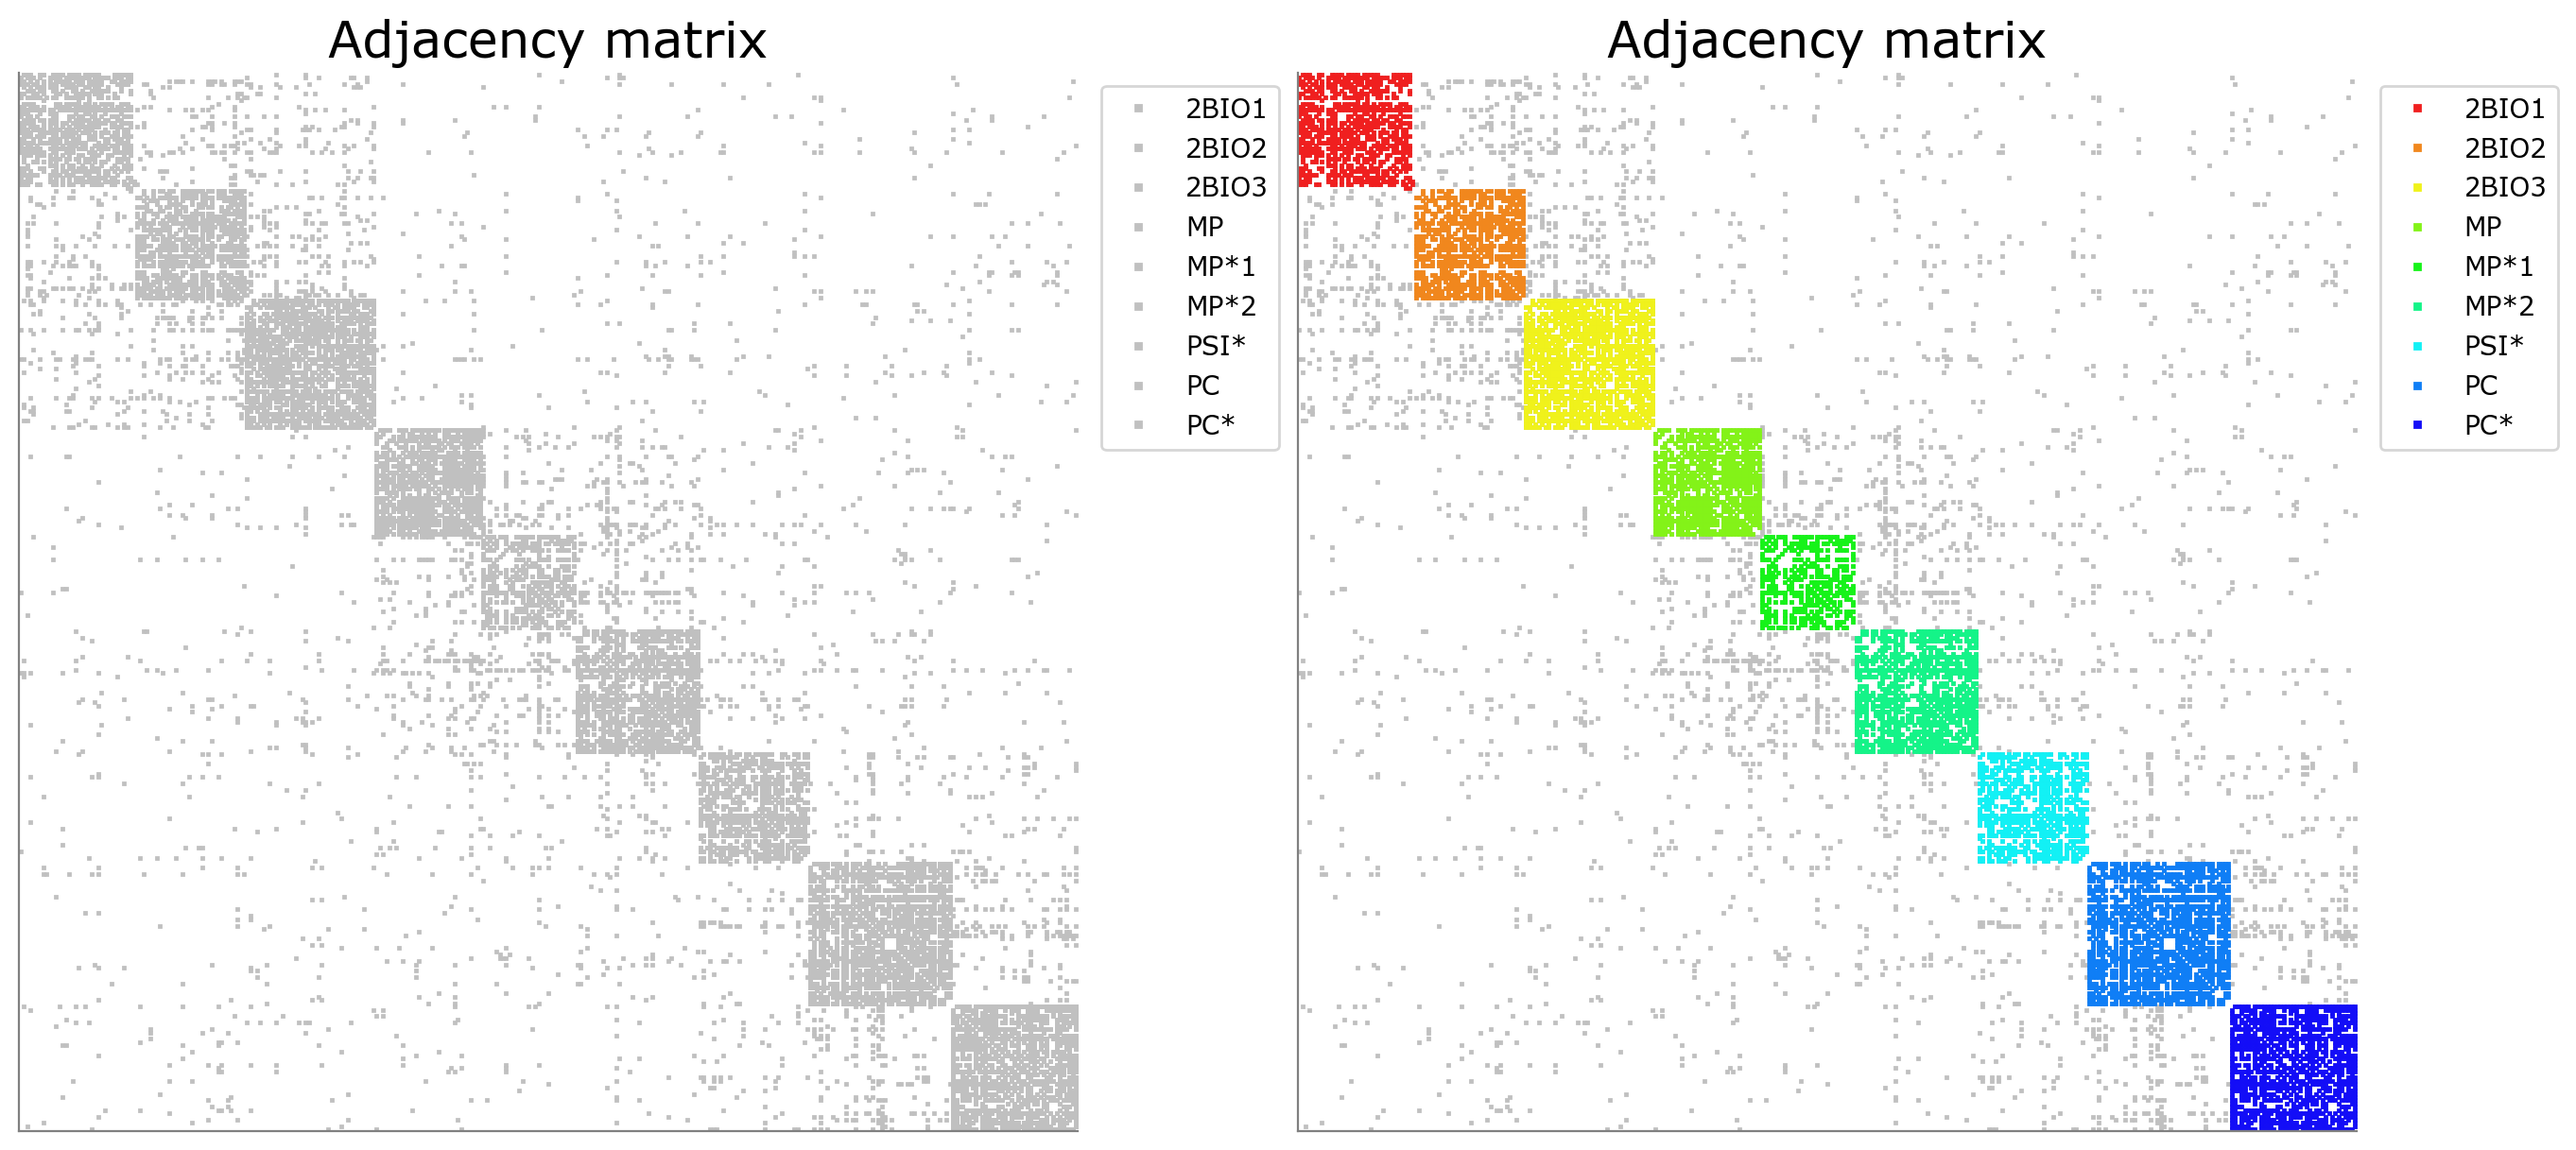

In [39]:
ehg, Ak = getEhgAk(name='highschool', k=[2])
plotHighSchoolAk(Ak, ehg)

# Degree Distribution

In [5]:
ehg = EmpiricalHyperGraph(name)
degree_dis = dict()
maxOrder_dis = dict()
for i in range(ehg.n):
    meta_l = meta[i]
    bh_l = BHpartition[i]
    if f'{meta_l}_{bh_l}' not in degree_dis.keys():
        degree_dis[f'{meta_l}_{bh_l}'] = dict()
    edge_index = ehg.H[[i], :].nonzero()[1]
    # print(edge_index)
    # degree dis
    order, degree_counts = np.unique(ehg.H[:, edge_index].sum(axis=0).flatten(), return_counts=True)
    for (o, d) in zip(order, degree_counts):
        if o not in degree_dis[f'{meta_l}_{bh_l}'].keys():
            degree_dis[f'{meta_l}_{bh_l}'][o] = dict()
        if d in degree_dis[f'{meta_l}_{bh_l}'][o].keys():
            degree_dis[f'{meta_l}_{bh_l}'][o][d] += 1
        else:
            degree_dis[f'{meta_l}_{bh_l}'][o][d] = 1
    if -1 not in degree_dis[f'{meta_l}_{bh_l}'].keys():
        degree_dis[f'{meta_l}_{bh_l}'][-1] = dict()
    if np.sum(degree_counts) in degree_dis[f'{meta_l}_{bh_l}'][-1].keys():
        degree_dis[f'{meta_l}_{bh_l}'][-1][np.sum(degree_counts)] += 1
    else:
        degree_dis[f'{meta_l}_{bh_l}'][-1][np.sum(degree_counts)] = 1
    # max order dis
    if f'{meta_l}_{bh_l}' not in maxOrder_dis.keys():
        maxOrder_dis[f'{meta_l}_{bh_l}'] = dict()
    maxOrder = np.max(order)
    if maxOrder not in maxOrder_dis[f'{meta_l}_{bh_l}'].keys():
        maxOrder_dis[f'{meta_l}_{bh_l}'][maxOrder] = 1
    else:
        maxOrder_dis[f'{meta_l}_{bh_l}'][maxOrder] += 1
degree_dis = {k: v for k, v in sorted(degree_dis.items(), key=lambda item: int(item[0].split('_')[1]))}
for lp in list(degree_dis.keys()):
    print(f'{lp}: {degree_dis[lp]}')

maxOrder_dis = {k: v for k, v in sorted(maxOrder_dis.items(), key=lambda item: int(item[0].split('_')[1]))}
for lp in list(maxOrder_dis.keys()):
    print(f'{lp}: {maxOrder_dis[lp]}')

Construct highschool hypergraph with 327 nodes, 7818 hyperedges and all possible k is [3, 4, 2, 5].
PC_0: {2: {24: 2, 10: 2, 28: 2, 44: 1, 22: 1, 13: 1, 33: 1, 9: 1, 29: 1}, 3: {11: 3, 3: 1, 4: 1, 2: 3, 5: 2, 14: 1}, -1: {35: 1, 13: 1, 32: 1, 55: 1, 24: 1, 33: 1, 29: 1, 15: 1, 44: 2, 9: 1, 12: 1}, 4: {1: 1}}
PC*_0: {2: {20: 1, 18: 1, 32: 1, 19: 1, 26: 1, 27: 1, 23: 1, 34: 1, 17: 1, 24: 1}, 3: {2: 4, 1: 1, 6: 1, 7: 2, 12: 1, 4: 1}, 4: {1: 4}, -1: {23: 1, 19: 1, 38: 1, 21: 2, 28: 1, 29: 1, 31: 1, 47: 1, 32: 1}}
MP*1_0: {2: {25: 2, 22: 2, 62: 1, 27: 2, 37: 2, 19: 3, 14: 1, 28: 1, 20: 3, 26: 1, 21: 1, 18: 1, 29: 1, 53: 1, 10: 1, 16: 1, 8: 2, 17: 1, 9: 1}, 3: {4: 2, 5: 1, 23: 1, 13: 1, 6: 4, 2: 5, 22: 1, 1: 3, 3: 1, 19: 1, 16: 1, 9: 2, 8: 1}, -1: {29: 1, 27: 3, 89: 1, 44: 2, 25: 2, 16: 2, 53: 1, 20: 1, 23: 1, 28: 2, 26: 1, 21: 2, 50: 1, 70: 1, 12: 1, 8: 2, 45: 1, 22: 1, 38: 1, 10: 1}, 4: {4: 2, 1: 5, 3: 1, 2: 3}}
PSI*_0: {2: {15: 1, 19: 1, 12: 1, 20: 2, 28: 1, 21: 1, 4: 1}, 3: {1: 3, 2: 1, 

In [8]:
def plotDegreeDis(meta_l, bh_l, order=None, ax=None, xlabel='degree', title="", yticks=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6), facecolor='lightskyblue', layout='constrained')
    # colors = gen_colors(colors_red[0], colors_blue[0], 4)
    colors = ["#193E8F", "#55B7E6", "#F09739", "#E53528"]
    if order is None:
        bottom = None
        for o in degree_dis[f'{meta_l}_{bh_l}'].keys():
            if o > 0:
                # no plot full degree
                x = list(degree_dis[f'{meta_l}_{bh_l}'][o].keys())
                y = list(degree_dis[f'{meta_l}_{bh_l}'][o].values())
                label = f'order {o}' if o > 1 else 'degree'
                bar_bottom = [bottom[d] if d in bottom.keys() else 0 for d in x] if bottom is not None else None
                ax.bar(x, y, bottom=bar_bottom, color=colors[o-2], label=label)
                if bottom is None:
                    bottom = dict()
                for i in range(len(x)):
                    if x[i] in bottom.keys():
                        bottom[x[i]] += y[i]
                    else:
                        bottom[x[i]] = y[i]
    else:
        x = list(degree_dis[f'{meta_l}_{bh_l}'][o].keys())
        y = list(degree_dis[f'{meta_l}_{bh_l}'][o].values())
        label = f'order {o}' if o > 1 else 'degree'
        ax.bar(x, y, label=label)
    ax.set_title(title, size=18)
    ax.set_xlabel(xlabel, size=12)
    ax.set_ylabel('#nodes', size=12)
    if yticks is not None:
        ax.set_yticks(yticks)
    # ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3, integer=True))
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.tick_params(axis='both', which='minor', labelsize=10)
    # ax.legend(fontsize=6)

In [7]:
def plotCompareDegreeDis(ax0, ax1, meta_l, ax2=None, yticks=None, xlabel=""):
    bh_l_dict = {
        "2BIO1": 1, 
        "2BIO2": 8,
        "2BIO3": (4, 5), 
        "MP": 2,
        "MP*1": 2,
        "MP*2": 2,
        "PC": 3, 
        "PC*": 7,
        "PSI*": 6
    }
    bh_l = bh_l_dict[meta_l]
    if meta_l == "2BIO3":
        plotDegreeDis(meta_l, bh_l[0], ax=ax0, xlabel=xlabel)
        plotDegreeDis(meta_l, bh_l[1], ax=ax2, xlabel=xlabel)
    else:
        plotDegreeDis(meta_l, bh_l, ax=ax0, xlabel=xlabel)
    ax1.sharex(ax0)
    bh_l = 0
    plotDegreeDis(meta_l, bh_l, ax=ax1, xlabel="", title=f'{meta_l}')

C:\Users\24391\AppData\Local\Temp\ipykernel_14144\609887954.py:61: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.1)


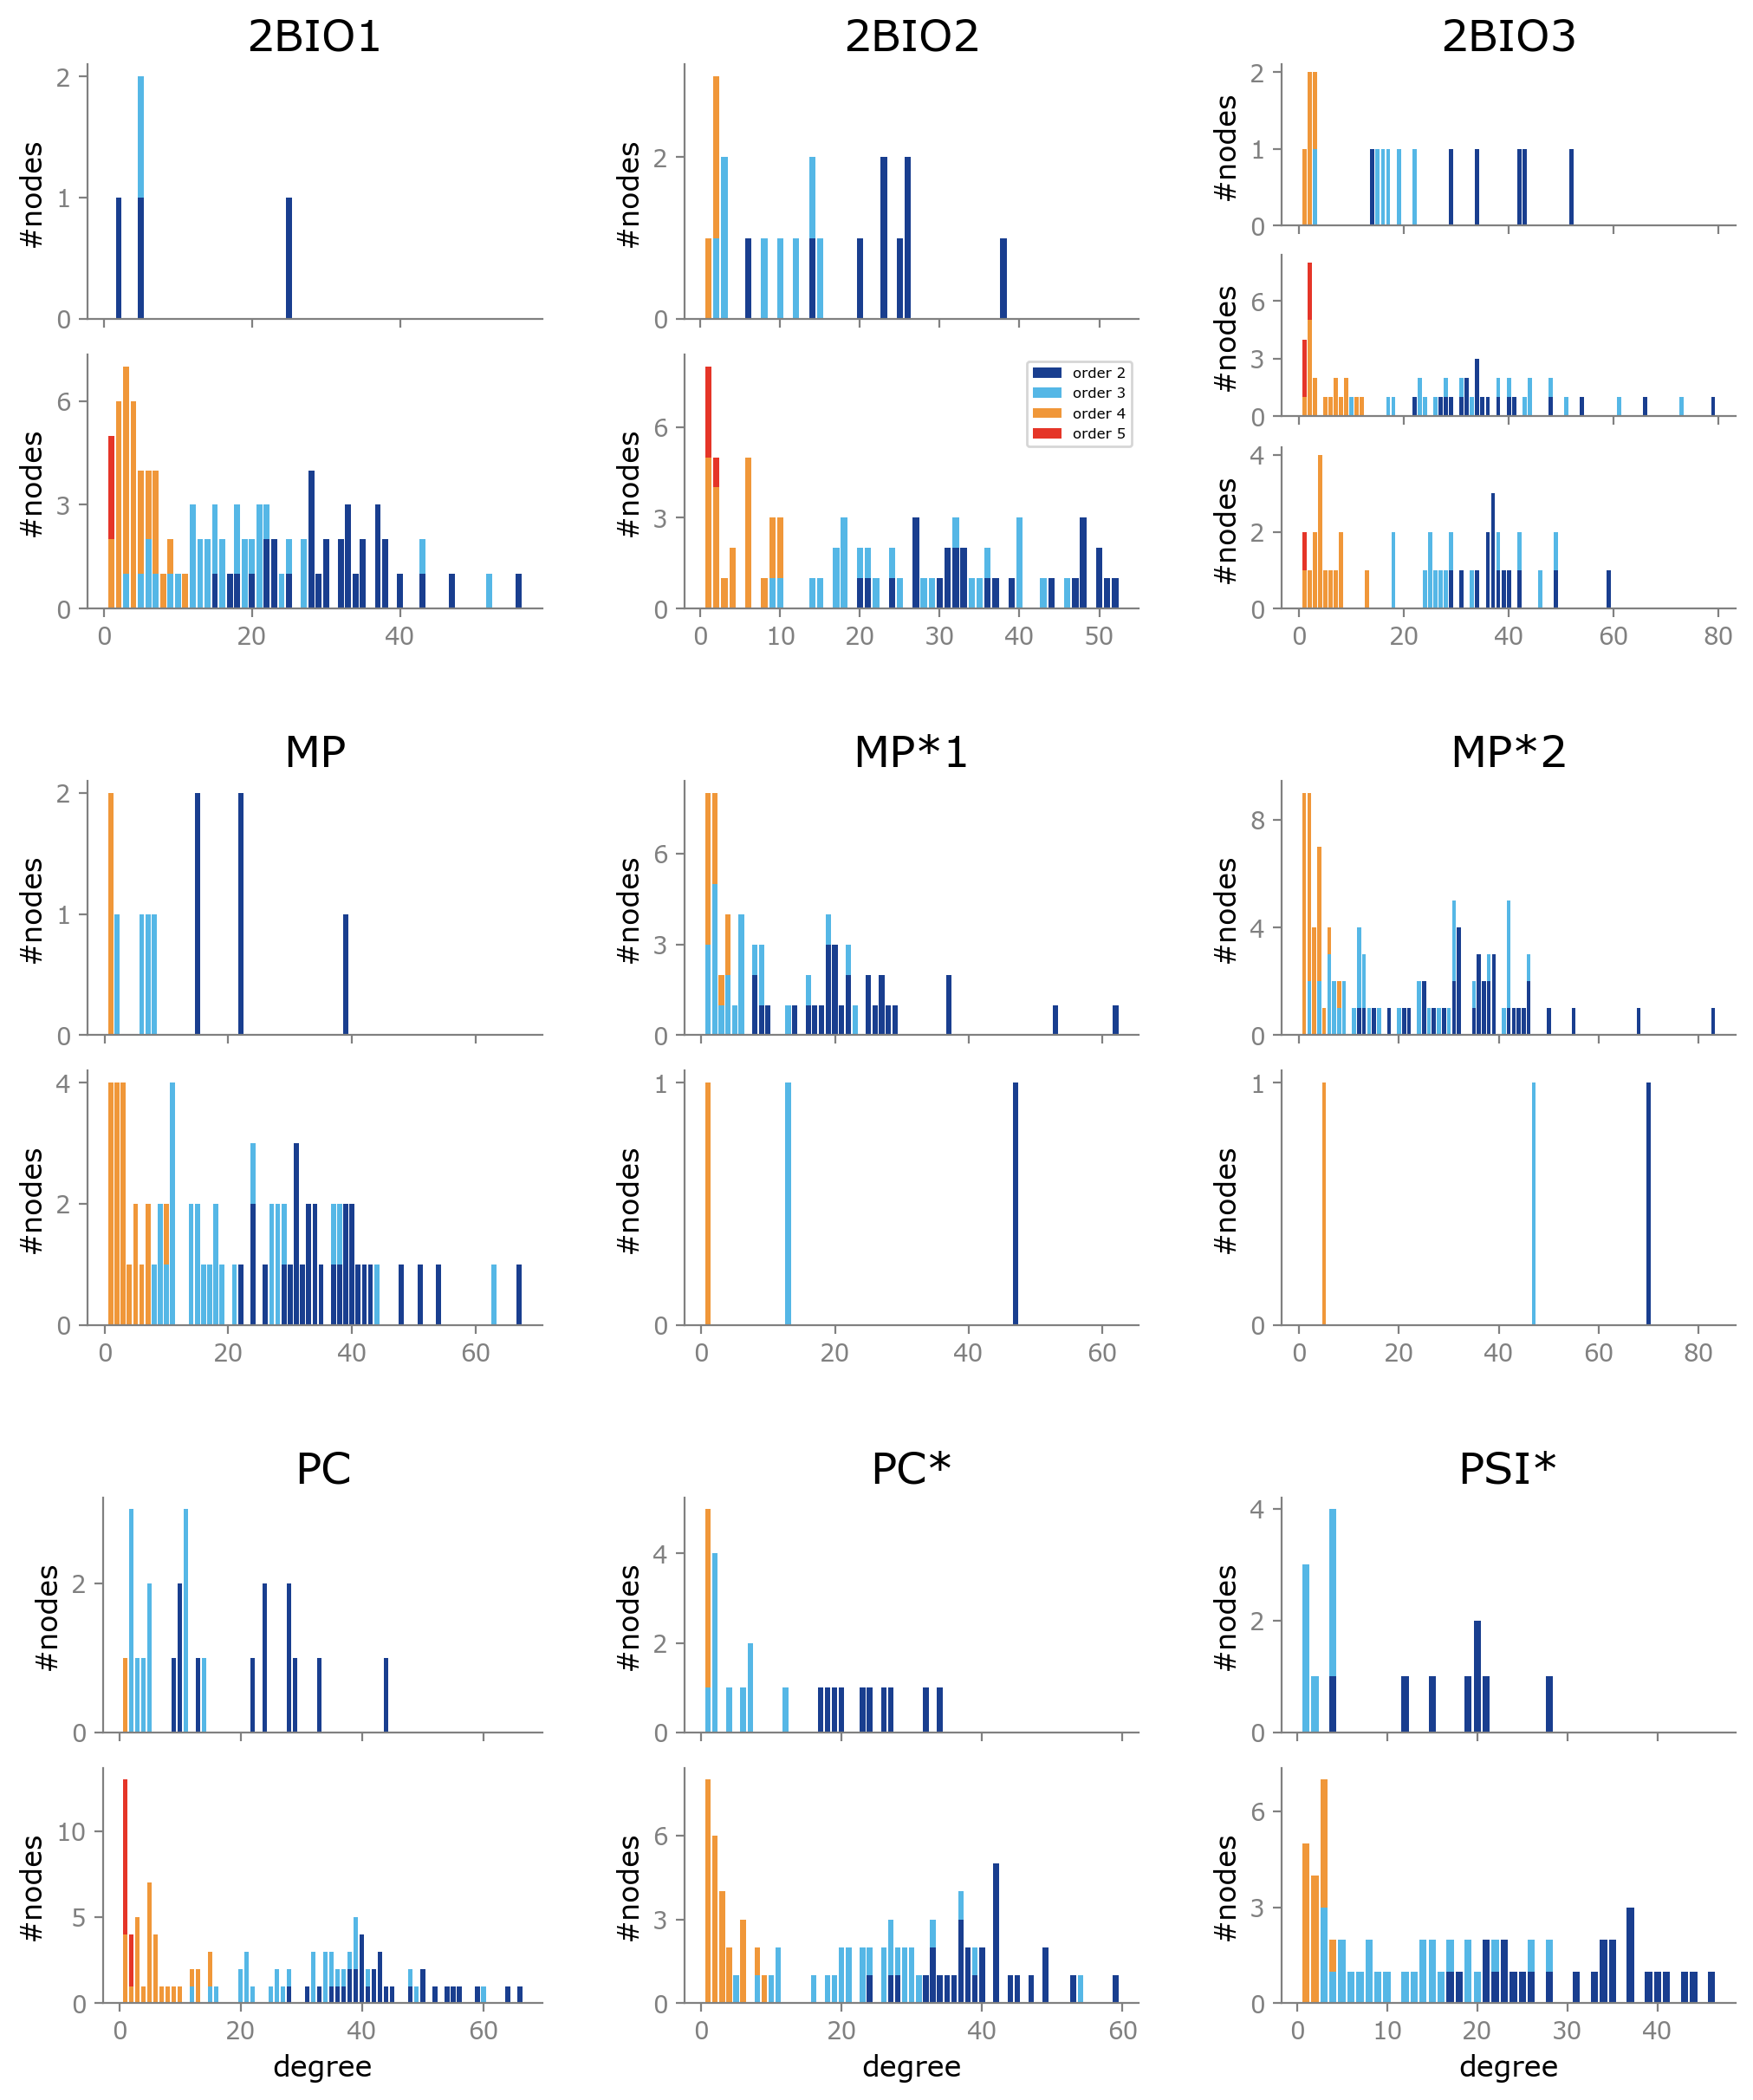

In [11]:
fullfig = plt.figure(figsize=(10, 12), layout="constrained")
subfigs = fullfig.subfigures(3, 3, wspace=0.1, hspace=0.1)

axs = subfigs[0][0].subplots(2, 1, sharex=True)
meta_l = "2BIO1"
ax0 = axs[1]
ax1 = axs[0]
plotCompareDegreeDis(ax0, ax1, meta_l)

axs = subfigs[0][1].subplots(2, 1, sharex=True)
meta_l = "2BIO2"
ax0 = axs[1]
ax1 = axs[0]
plotCompareDegreeDis(ax0, ax1, meta_l)
ax0.legend(fontsize=6, loc="upper right")

axs = subfigs[0][2].subplots(3, 1, sharex=True)
meta_l = "2BIO3"
ax0 = axs[1]
ax1 = axs[0]
ax2 = axs[2]
plotCompareDegreeDis(ax0, ax1, meta_l, ax2)

axs = subfigs[1][0].subplots(2, 1, sharex=True)
meta_l = "MP"
ax0 = axs[1]
ax1 = axs[0]
plotCompareDegreeDis(ax0, ax1, meta_l)

axs = subfigs[1][1].subplots(2, 1, sharex=True)
meta_l = "MP*1"
ax0 = axs[1]
ax1 = axs[0]
plotCompareDegreeDis(ax0, ax1, meta_l)

axs = subfigs[1][2].subplots(2, 1, sharex=True)
meta_l = "MP*2"
ax0 = axs[1]
ax1 = axs[0]
plotCompareDegreeDis(ax0, ax1, meta_l)

axs = subfigs[2][0].subplots(2, 1, sharex=True)
meta_l = "PC"
ax0 = axs[1]
ax1 = axs[0]
plotCompareDegreeDis(ax0, ax1, meta_l, xlabel="degree")

axs = subfigs[2][1].subplots(2, 1, sharex=True)
meta_l = "PC*"
ax0 = axs[1]
ax1 = axs[0]
plotCompareDegreeDis(ax0, ax1, meta_l, xlabel="degree")

axs = subfigs[2][2].subplots(2, 1, sharex=True)
meta_l = "PSI*"
ax0 = axs[1]
ax1 = axs[0]
plotCompareDegreeDis(ax0, ax1, meta_l, xlabel="degree")


plt.subplots_adjust(hspace=0.1)
# plt.tight_layout()
save_path = f"./_Figure/Hyper/" + f"High_school_DegreeDis.pdf"
# plt.tight_layout()
# plt.subplots_adjust(left=None, bottom=0.7, right=None, top=None, wspace=None, hspace=0.1)
plt.savefig(save_path, dpi=600)

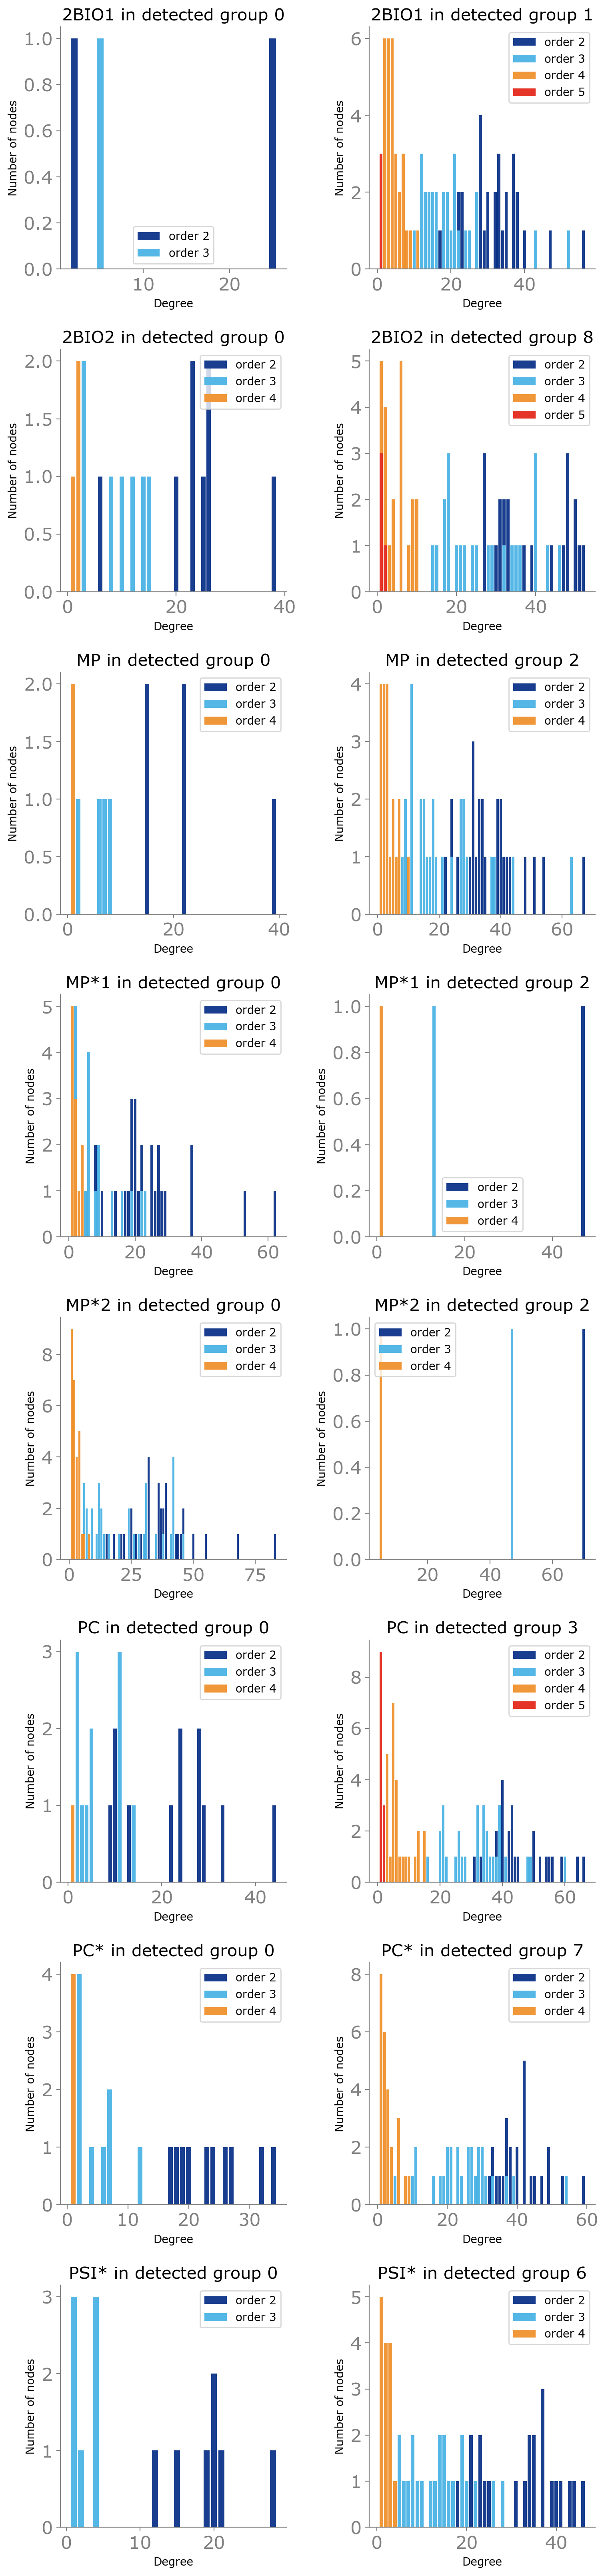

In [45]:
fig = plt.figure(figsize=(8, 36))
widths = [4, 4]
heights = [4, 4, 4, 4, 4, 4, 4, 4, 4]
spec5 = fig.add_gridspec(ncols=2, nrows=9, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
meta_l = "2BIO1"
bh_l = 0
plotDegreeDis(meta_l, bh_l, ax=ax)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
meta_l = "2BIO1"
bh_l = 1
plotDegreeDis(meta_l, bh_l, ax=ax)

row = 1
col = 0
ax = fig.add_subplot(spec5[row, col])
meta_l = "2BIO2"
bh_l = 0
plotDegreeDis(meta_l, bh_l, ax=ax)

row = 1
col = 1
ax = fig.add_subplot(spec5[row, col])
meta_l = "2BIO2"
bh_l = 8
plotDegreeDis(meta_l, bh_l, ax=ax)

row = 2
col = 0
ax = fig.add_subplot(spec5[row, col])
meta_l = "MP"
bh_l = 0
plotDegreeDis(meta_l, bh_l, ax=ax)

row = 2
col = 1
ax = fig.add_subplot(spec5[row, col])
meta_l = "MP"
bh_l = 2
plotDegreeDis(meta_l, bh_l, ax=ax)

row = 3
col = 0
ax = fig.add_subplot(spec5[row, col])
meta_l = "MP*1"
bh_l = 0
plotDegreeDis(meta_l, bh_l, ax=ax)

row = 3
col = 1
ax = fig.add_subplot(spec5[row, col])
meta_l = "MP*1"
bh_l = 2
plotDegreeDis(meta_l, bh_l, ax=ax)

row = 4
col = 0
ax = fig.add_subplot(spec5[row, col])
meta_l = "MP*2"
bh_l = 0
plotDegreeDis(meta_l, bh_l, ax=ax)

row = 4
col = 1
ax = fig.add_subplot(spec5[row, col])
meta_l = "MP*2"
bh_l = 2
plotDegreeDis(meta_l, bh_l, ax=ax)

row = 5
col = 0
ax = fig.add_subplot(spec5[row, col])
meta_l = "PC"
bh_l = 0
plotDegreeDis(meta_l, bh_l, ax=ax)

row = 5
col = 1
ax = fig.add_subplot(spec5[row, col])
meta_l = "PC"
bh_l = 3
plotDegreeDis(meta_l, bh_l, ax=ax)

row = 6
col = 0
ax = fig.add_subplot(spec5[row, col])
meta_l = "PC*"
bh_l = 0
plotDegreeDis(meta_l, bh_l, ax=ax)

row = 6
col = 1
ax = fig.add_subplot(spec5[row, col])
meta_l = "PC*"
bh_l = 7
plotDegreeDis(meta_l, bh_l, ax=ax)

row = 7
col = 0
ax = fig.add_subplot(spec5[row, col])
meta_l = "PSI*"
bh_l = 0
plotDegreeDis(meta_l, bh_l, ax=ax)

row = 7
col = 1
ax = fig.add_subplot(spec5[row, col])
meta_l = "PSI*"
bh_l = 6
plotDegreeDis(meta_l, bh_l, ax=ax)

plt.tight_layout()


# Order Distribution

In [13]:
def plotMaxOrderDis(meta_l, bh_l, ax=None, color="#EF767A", xlabel="", title=""):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6), facecolor='lightskyblue', layout='constrained')
    # colors = gen_colors(colors_red[0], colors_blue[0], 4)
    x = list(maxOrder_dis[f'{meta_l}_{bh_l}'].keys())
    y = list(maxOrder_dis[f'{meta_l}_{bh_l}'].values())
    # label = f'MaxOrder {o} degree' if o > 1 else 'degree'
    ax.bar(x, y, color=color)
    ax.set_title(title, size=18)
    ax.set_xticks([2,3,4,5])
    ax.set_xlabel(xlabel, size=12)
    ax.set_ylabel('#nodes', size=12)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3, integer=True))
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.tick_params(axis='both', which='minor', labelsize=10)
    # ax.legend()

In [14]:
def plotCompareOrderDis(ax0, ax1, meta_l, ax2=None, yticks=None, xlabel=""):
    bh_l_dict = {
        "2BIO1": 1, 
        "2BIO2": 8,
        "2BIO3": (4, 5), 
        "MP": 2,
        "MP*1": 2,
        "MP*2": 2,
        "PC": 3, 
        "PC*": 7,
        "PSI*": 6
    }
    bh_l = bh_l_dict[meta_l]
    if meta_l == "2BIO3":
        plotMaxOrderDis(meta_l, bh_l[0], ax=ax0, xlabel=xlabel)
        plotMaxOrderDis(meta_l, bh_l[1], ax=ax2, xlabel=xlabel)
    else:
        plotMaxOrderDis(meta_l, bh_l, ax=ax0, xlabel=xlabel)
    ax1.sharex(ax0)
    bh_l = 0
    plotMaxOrderDis(meta_l, bh_l, ax=ax1, xlabel="", title=f'{meta_l}')

C:\Users\24391\AppData\Local\Temp\ipykernel_14144\3293960513.py:61: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.1)


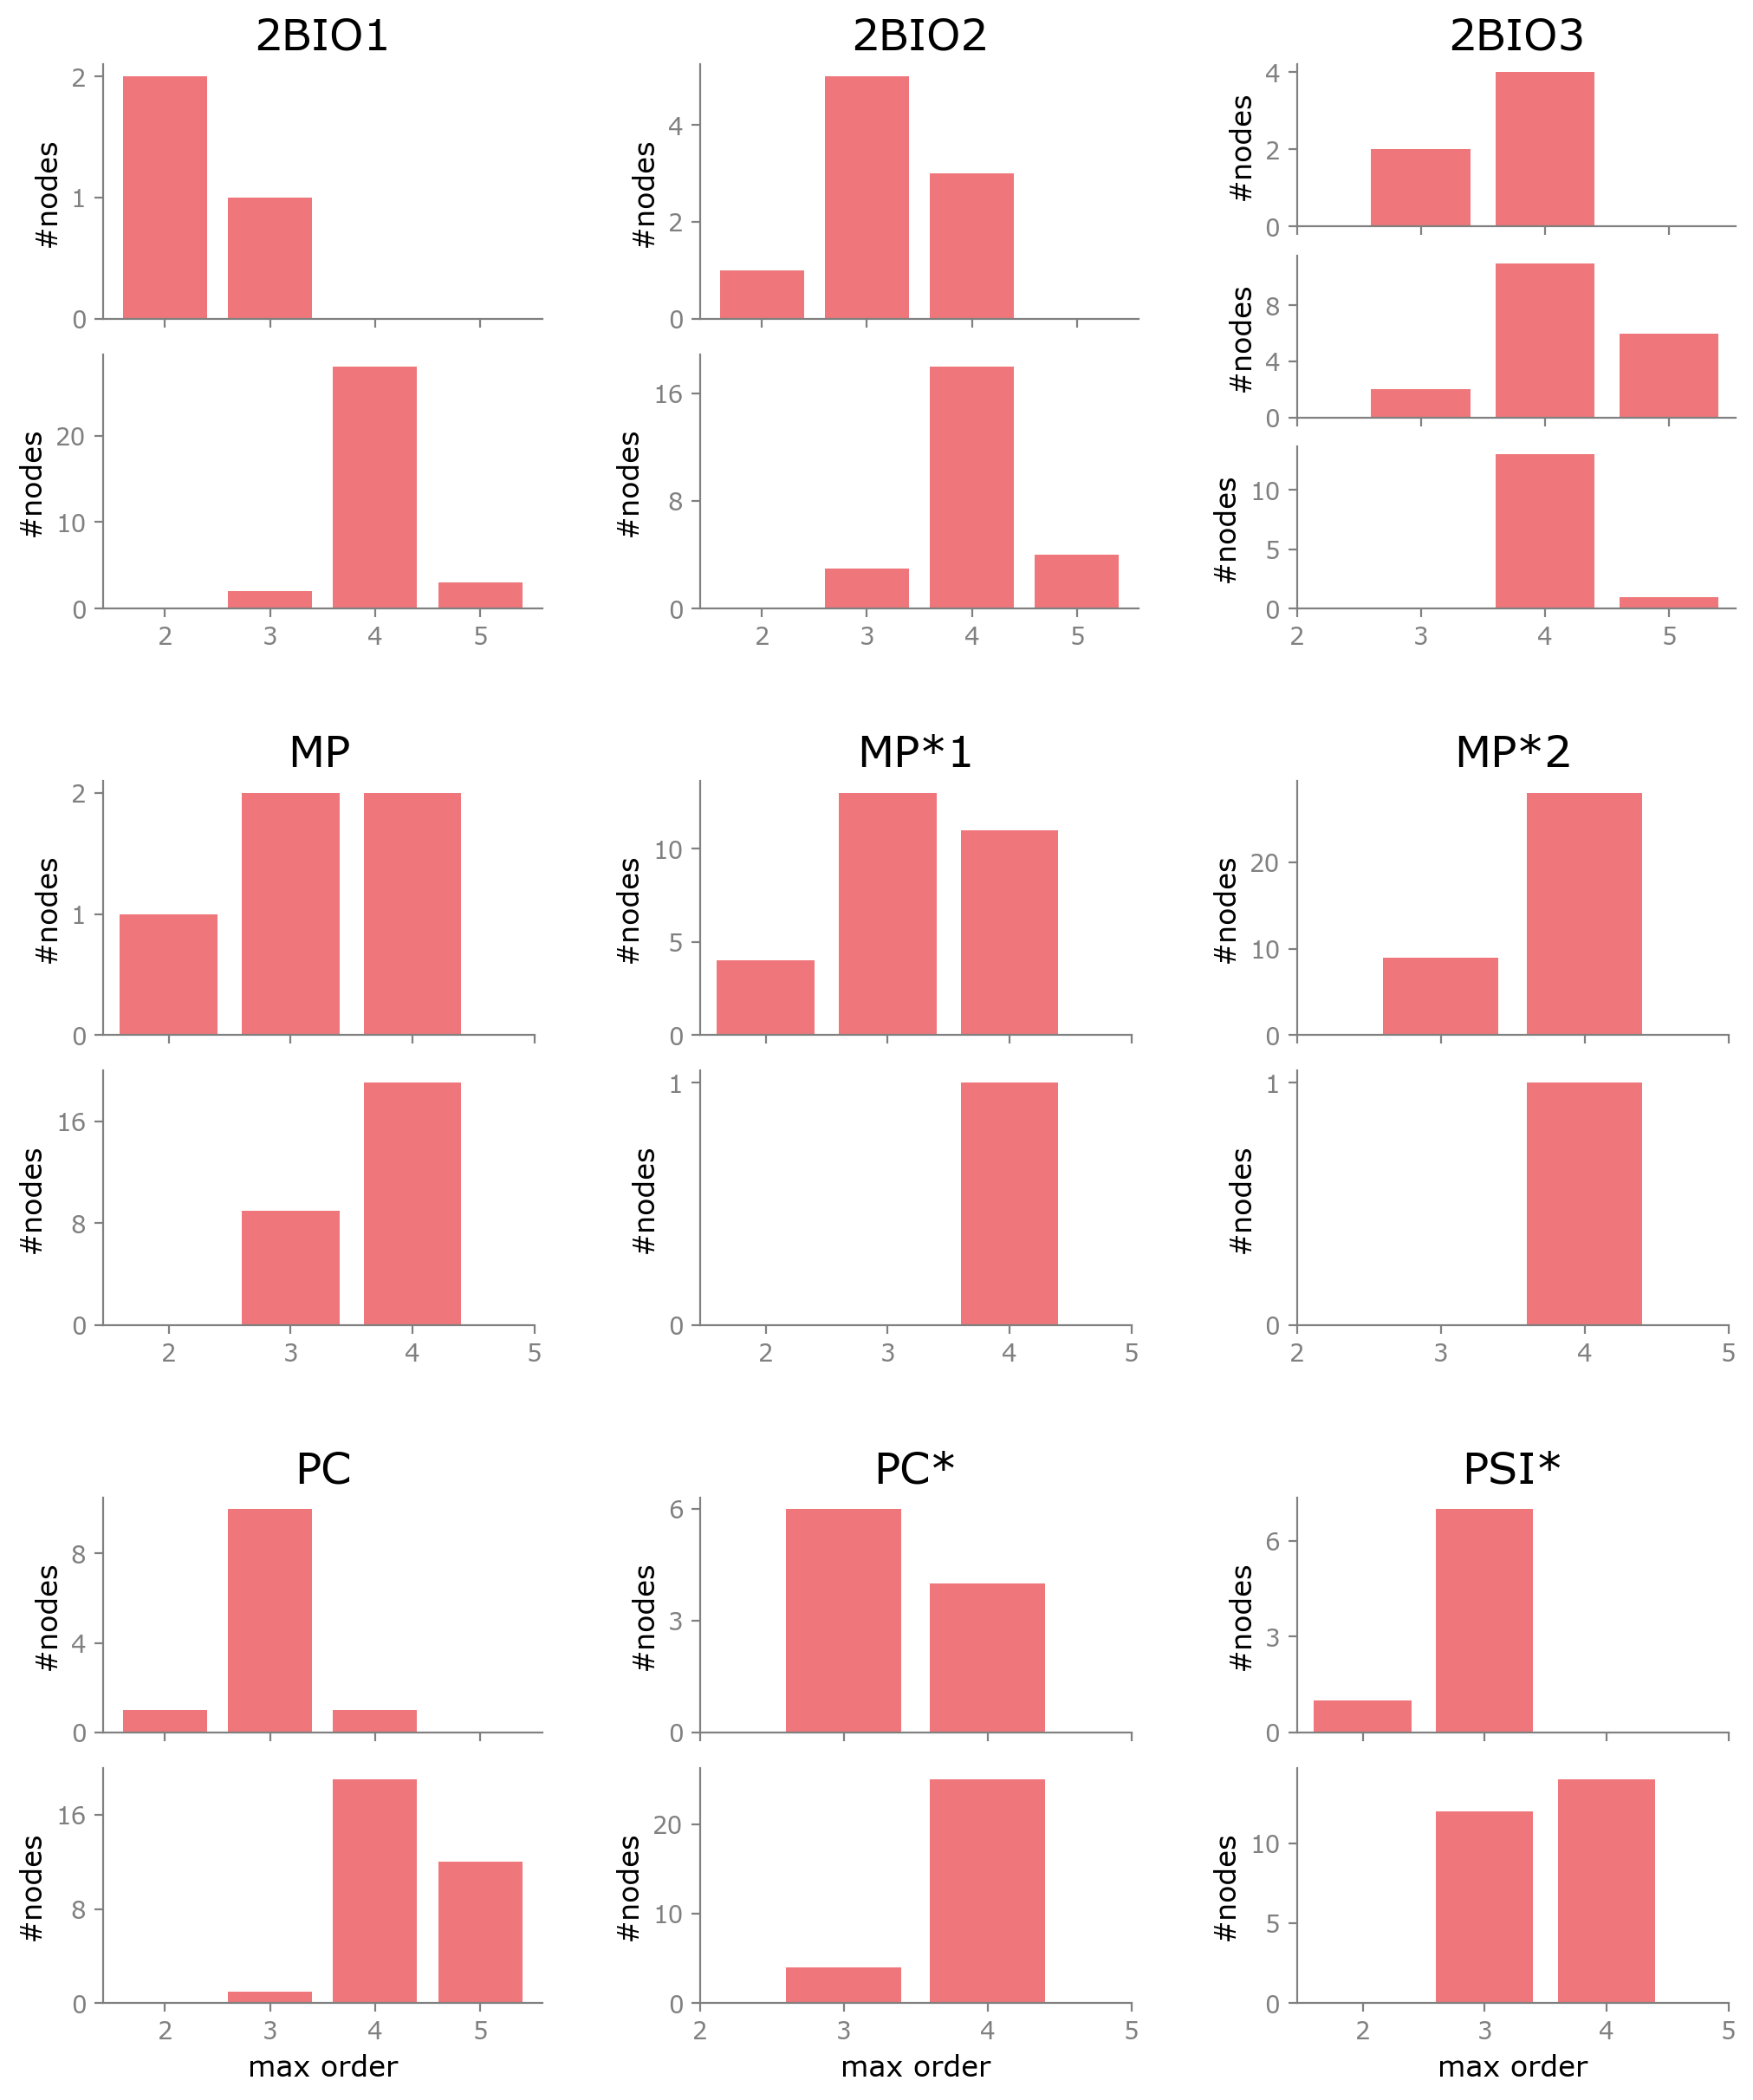

In [16]:
fullfig = plt.figure(figsize=(10, 12), layout="constrained")
subfigs = fullfig.subfigures(3, 3, wspace=0.1, hspace=0.1)

axs = subfigs[0][0].subplots(2, 1, sharex=True)
meta_l = "2BIO1"
ax0 = axs[1]
ax1 = axs[0]
plotCompareOrderDis(ax0, ax1, meta_l)

axs = subfigs[0][1].subplots(2, 1, sharex=True)
meta_l = "2BIO2"
ax0 = axs[1]
ax1 = axs[0]
plotCompareOrderDis(ax0, ax1, meta_l)
# ax0.legend(fontsize=6, loc="upper right")

axs = subfigs[0][2].subplots(3, 1, sharex=True)
meta_l = "2BIO3"
ax0 = axs[1]
ax1 = axs[0]
ax2 = axs[2]
plotCompareOrderDis(ax0, ax1, meta_l, ax2)

axs = subfigs[1][0].subplots(2, 1, sharex=True)
meta_l = "MP"
ax0 = axs[1]
ax1 = axs[0]
plotCompareOrderDis(ax0, ax1, meta_l)

axs = subfigs[1][1].subplots(2, 1, sharex=True)
meta_l = "MP*1"
ax0 = axs[1]
ax1 = axs[0]
plotCompareOrderDis(ax0, ax1, meta_l)

axs = subfigs[1][2].subplots(2, 1, sharex=True)
meta_l = "MP*2"
ax0 = axs[1]
ax1 = axs[0]
plotCompareOrderDis(ax0, ax1, meta_l)

axs = subfigs[2][0].subplots(2, 1, sharex=True)
meta_l = "PC"
ax0 = axs[1]
ax1 = axs[0]
plotCompareOrderDis(ax0, ax1, meta_l, xlabel="max order")

axs = subfigs[2][1].subplots(2, 1, sharex=True)
meta_l = "PC*"
ax0 = axs[1]
ax1 = axs[0]
plotCompareOrderDis(ax0, ax1, meta_l, xlabel="max order")

axs = subfigs[2][2].subplots(2, 1, sharex=True)
meta_l = "PSI*"
ax0 = axs[1]
ax1 = axs[0]
plotCompareOrderDis(ax0, ax1, meta_l, xlabel="max order")


plt.subplots_adjust(hspace=0.1)
# plt.tight_layout()
save_path = f"./_Figure/Hyper/" + f"High_school_MaxOrderDis.pdf"
# plt.tight_layout()
# plt.subplots_adjust(left=None, bottom=0.7, right=None, top=None, wspace=None, hspace=0.1)
plt.savefig(save_path, dpi=600)

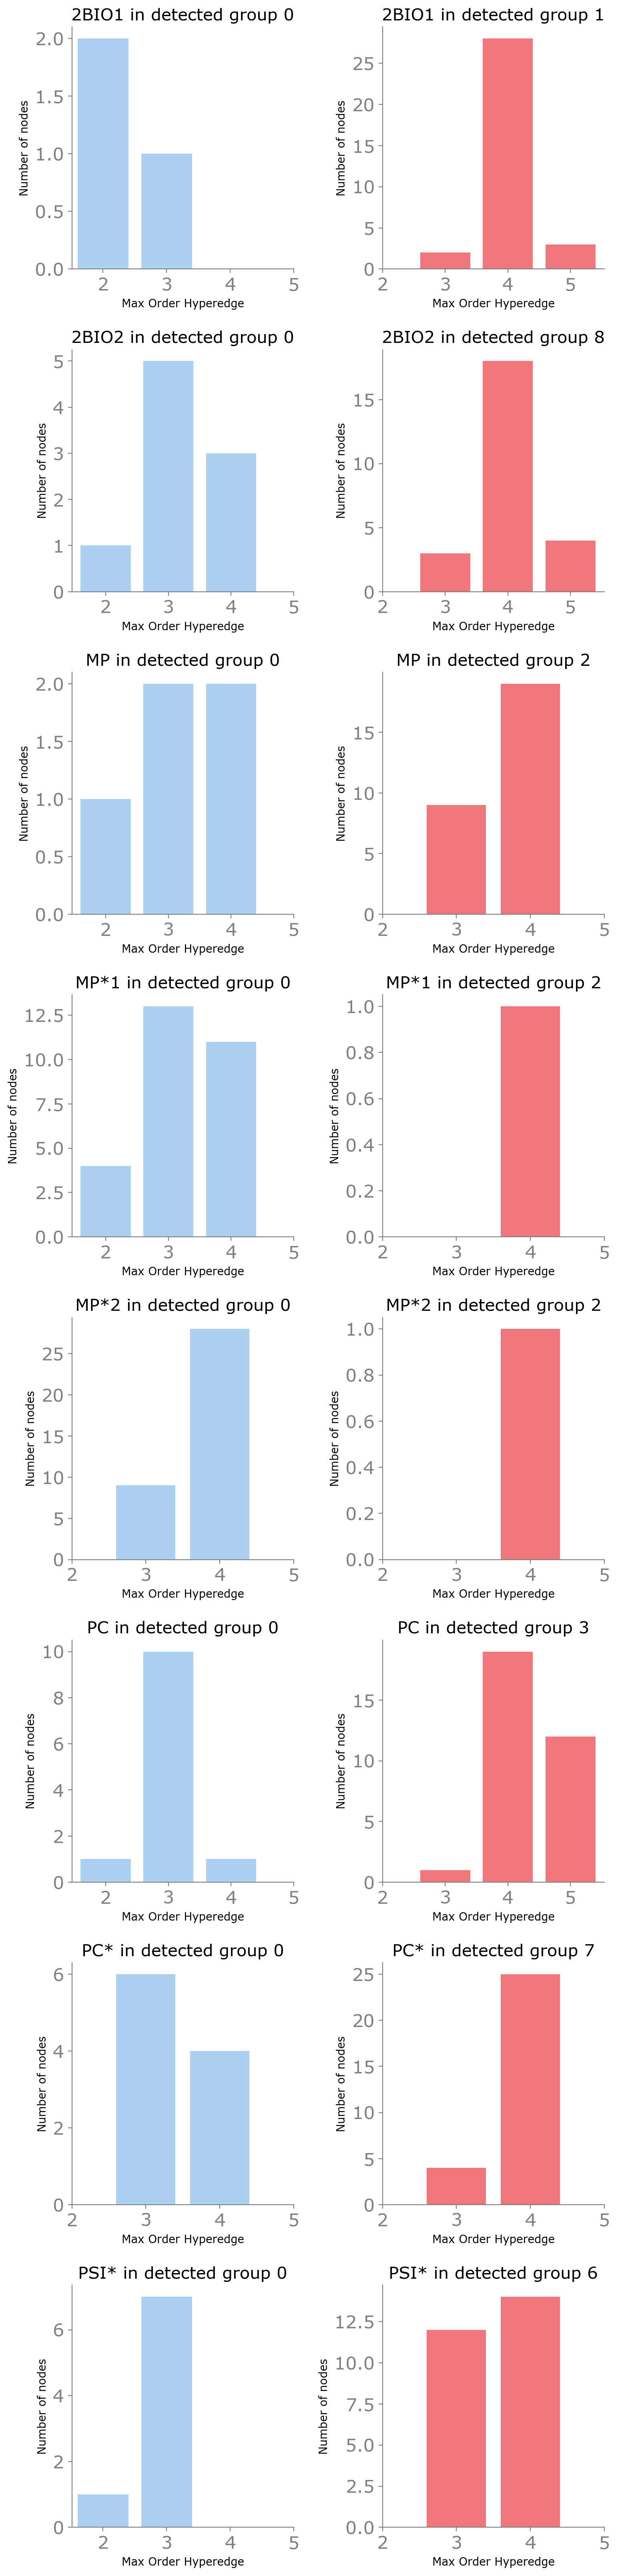

In [35]:
fig = plt.figure(figsize=(8, 36))
widths = [4, 4]
heights = [4, 4, 4, 4, 4, 4, 4, 4, 4]
spec5 = fig.add_gridspec(ncols=2, nrows=9, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
meta_l = "2BIO1"
bh_l = 0
plotMaxOrderDis(meta_l, bh_l, ax=ax, color="#ABD0F1")

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
meta_l = "2BIO1"
bh_l = 1
plotMaxOrderDis(meta_l, bh_l, ax=ax)

row = 1
col = 0
ax = fig.add_subplot(spec5[row, col])
meta_l = "2BIO2"
bh_l = 0
plotMaxOrderDis(meta_l, bh_l, ax=ax, color="#ABD0F1")

row = 1
col = 1
ax = fig.add_subplot(spec5[row, col])
meta_l = "2BIO2"
bh_l = 8
plotMaxOrderDis(meta_l, bh_l, ax=ax)

row = 2
col = 0
ax = fig.add_subplot(spec5[row, col])
meta_l = "MP"
bh_l = 0
plotMaxOrderDis(meta_l, bh_l, ax=ax, color="#ABD0F1")

row = 2
col = 1
ax = fig.add_subplot(spec5[row, col])
meta_l = "MP"
bh_l = 2
plotMaxOrderDis(meta_l, bh_l, ax=ax)

row = 3
col = 0
ax = fig.add_subplot(spec5[row, col])
meta_l = "MP*1"
bh_l = 0
plotMaxOrderDis(meta_l, bh_l, ax=ax, color="#ABD0F1")

row = 3
col = 1
ax = fig.add_subplot(spec5[row, col])
meta_l = "MP*1"
bh_l = 2
plotMaxOrderDis(meta_l, bh_l, ax=ax)

row = 4
col = 0
ax = fig.add_subplot(spec5[row, col])
meta_l = "MP*2"
bh_l = 0
plotMaxOrderDis(meta_l, bh_l, ax=ax, color="#ABD0F1")

row = 4
col = 1
ax = fig.add_subplot(spec5[row, col])
meta_l = "MP*2"
bh_l = 2
plotMaxOrderDis(meta_l, bh_l, ax=ax)

row = 5
col = 0
ax = fig.add_subplot(spec5[row, col])
meta_l = "PC"
bh_l = 0
plotMaxOrderDis(meta_l, bh_l, ax=ax, color="#ABD0F1")

row = 5
col = 1
ax = fig.add_subplot(spec5[row, col])
meta_l = "PC"
bh_l = 3
plotMaxOrderDis(meta_l, bh_l, ax=ax)

row = 6
col = 0
ax = fig.add_subplot(spec5[row, col])
meta_l = "PC*"
bh_l = 0
plotMaxOrderDis(meta_l, bh_l, ax=ax, color="#ABD0F1")

row = 6
col = 1
ax = fig.add_subplot(spec5[row, col])
meta_l = "PC*"
bh_l = 7
plotMaxOrderDis(meta_l, bh_l, ax=ax)

row = 7
col = 0
ax = fig.add_subplot(spec5[row, col])
meta_l = "PSI*"
bh_l = 0
plotMaxOrderDis(meta_l, bh_l, ax=ax, color="#ABD0F1")

row = 7
col = 1
ax = fig.add_subplot(spec5[row, col])
meta_l = "PSI*"
bh_l = 6
plotMaxOrderDis(meta_l, bh_l, ax=ax)

plt.tight_layout()


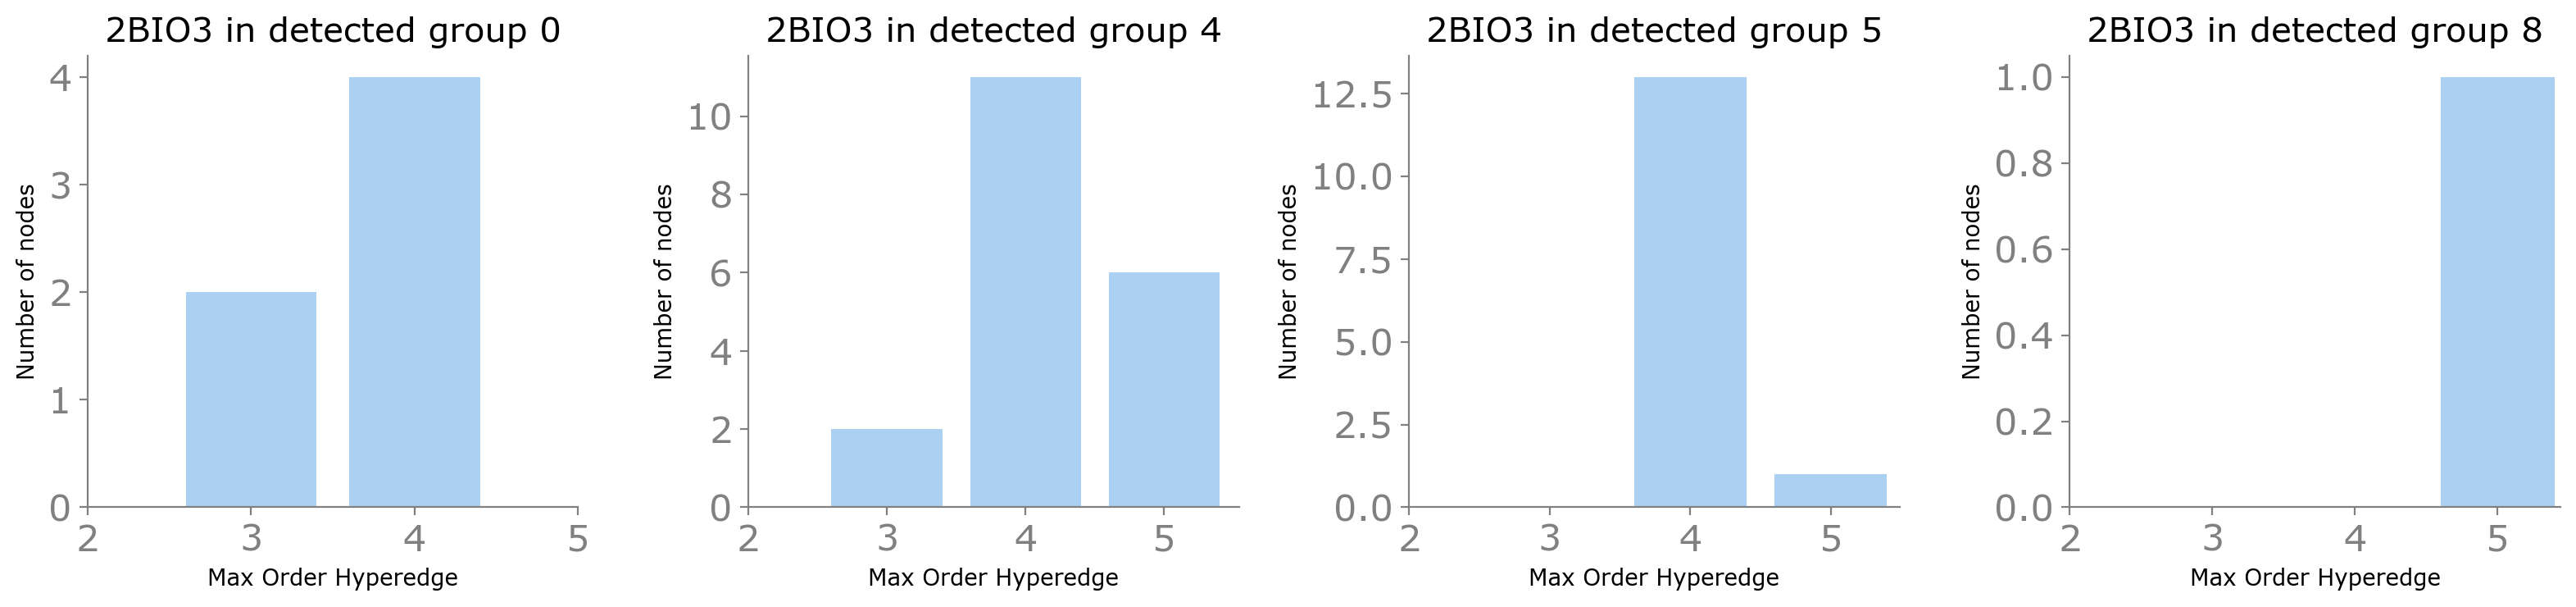

In [38]:
fig = plt.figure(figsize=(16, 4))
widths = [4, 4, 4, 4]
heights = [4]
spec5 = fig.add_gridspec(ncols=4, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
meta_l = "2BIO3"
bh_l = 0
plotMaxOrderDis(meta_l, bh_l, ax=ax, color="#ABD0F1")

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
meta_l = "2BIO3"
bh_l = 4
plotMaxOrderDis(meta_l, bh_l, ax=ax, color="#ABD0F1")

row = 0
col = 2
ax = fig.add_subplot(spec5[row, col])
meta_l = "2BIO3"
bh_l = 5
plotMaxOrderDis(meta_l, bh_l, ax=ax, color="#ABD0F1")

row = 0
col = 3
ax = fig.add_subplot(spec5[row, col])
meta_l = "2BIO3"
bh_l = 8
plotMaxOrderDis(meta_l, bh_l, ax=ax, color="#ABD0F1")
plt.tight_layout()

# Observe Spectral

In [20]:
partition_names = ["2BIO1", '2BIO2', '2BIO3','MP', 'MP*1', 'MP*2','PSI*', 'PC', 'PC*']
metaIndex = [partition_names.index(m) for m in meta]
metaI, metaC = np.unique(metaIndex, return_counts=True)
reorder_index = np.argsort(metaIndex)

In [23]:
order_count = dict(zip(edge_order, edge_count))
print(order_count)
ds = dict()
for o in order_count:
    ds[o] = o * order_count[o] / ehg.n
bulk = 0
for k in ehg.Ks:
    bulk += ds[k] * (k - 1)
bulk = np.sqrt(bulk)
print(f'bulk is {bulk}')

{2: 5498, 3: 2091, 4: 222, 5: 7}
bulk is 8.97601288654654


Construct $BH_8.97601288654654$: 100%|██████████████████████████████████████████████████| 4/4 [00:00<00:00, 258.16it/s]


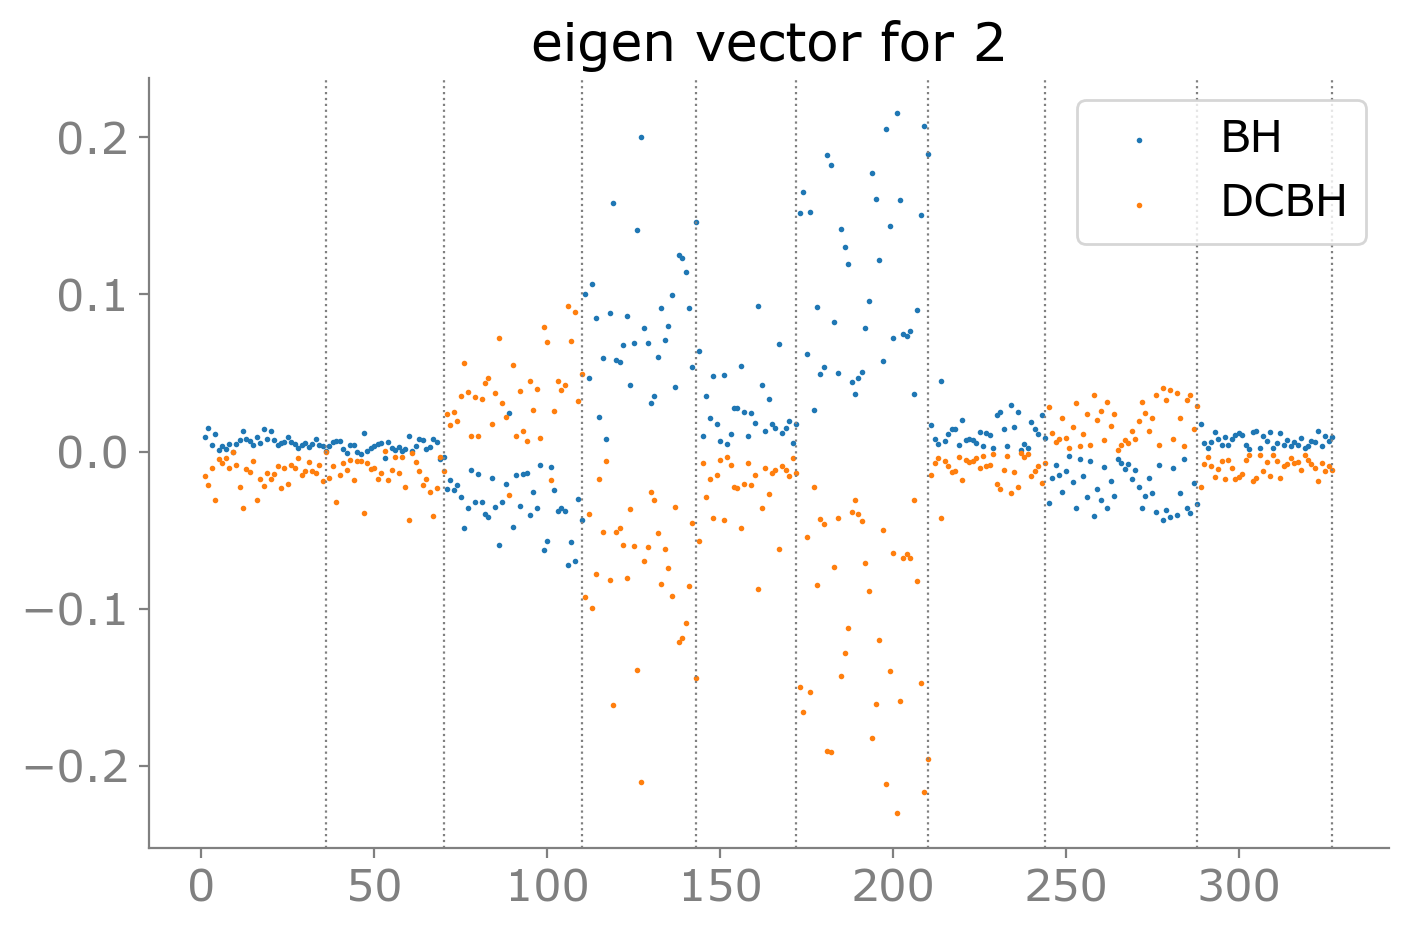

In [47]:
lambdas = [118.50022710316571, 112.06911062452723, 90.48105363311699, 88.38237576230273, 81.50679933238399, 75.1703060713963, 
          64.07948862937242, 57.035713964328785, 51.691325162075955]
eig_index = 2
DCBH = ehg.get_operator('BH', r=lambdas[eig_index])
BH = ehg.get_operator('BH', r=bulk)
which = 'SA'
_, DCBH_eig_vec = eigsh(DCBH, eig_index+1, which=which, tol=1e-6)
DCBH_eig_vec = DCBH_eig_vec[:, eig_index][reorder_index]
_, BH_eig_vec = eigsh(BH, eig_index+1, which=which, tol=1e-6)
BH_eig_vec = BH_eig_vec[:, eig_index][reorder_index]
plt.scatter(np.linspace(1, ehg.n, ehg.n), BH_eig_vec, s=1, label=f'BH')
plt.scatter(np.linspace(1, ehg.n, ehg.n), DCBH_eig_vec, s=1, label=f'DCBH')
for i in range(9):
    cummulation_count = np.sum(metaC[:i+1])
    plt.axvline(cummulation_count, color='gray', lw=0.8, ls=':')
plt.title(f'eigen vector for {eig_index}')
plt.legend()


# Visualize Communities

In [5]:
def reorder_partition(partition, meta, uniqueMeta=None):
    cm, cm_df = visualMetaCM(partition, meta)
    uniquePartition = np.unique(partition)
    uniqueMeta = np.unique(meta) if uniqueMeta is None else uniqueMeta
    partition_score = np.zeros(np.size(uniquePartition))
    for i in range(np.size(uniquePartition)):
        morelikely_j = np.argmax(cm[i, :])
        partition_score[i] = morelikely_j
        # for j in range(np.size(uniqueMeta)):
        #     partition_score[i] += (j+1) * cm[j, i]
    sort_index = np.argsort(partition_score)
    partition_map = dict()
    for i in range(np.size(sort_index)):
        partition_map[sort_index[i]] = i
    reorder_partition = np.zeros(np.size(partition))
    for i in range(np.size(partition)):
        reorder_partition[i] = partition_map[partition[i]]
    return reorder_partition, partition_score[sort_index]

In [9]:
# Construct EdgeList
edgeList = []
for hedge_id in range(ehg.e):
    hedge = csc_matrix(ehg.H).getcol(hedge_id).nonzero()[0]
    edgeList.append(hedge)
hgx_hypergraph = hgx.core.hypergraph.Hypergraph(edgeList)

In [6]:
# Metadata incidence matrix
u_meta = np.zeros(shape=(ehg.n, np.size(np.unique(meta))))
meta_labels = ['2BIO1', '2BIO2', '2BIO3', 'MP', 'MP*1', 'MP*2', 'PC', 'PC*', 'PSI*']
for i in range(ehg.n):
    u_meta[i][meta_labels.index(meta[i])] = 1

In [7]:
# reorder partition incidence matrix
reordered_partition, _ = reorder_partition(BHpartition, meta, uniqueMeta=meta_labels)
u_partition = np.zeros(shape=(ehg.n, givenNumGroup))
for i in range(ehg.n):
    u_partition[i][int(reordered_partition[i])] = 1

[[33.  0.  0.  0.  0.  3.  0.  0.  0.]
 [ 0. 25.  0.  0.  0.  9.  0.  0.  0.]
 [ 0.  1. 19. 14.  0.  6.  0.  0.  0.]
 [ 0.  0.  0.  0. 28.  5.  0.  0.  0.]
 [ 0.  0.  0.  0.  1. 28.  0.  0.  0.]
 [ 0.  0.  0.  0.  1. 37.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. 12. 32.  0.  0.]
 [ 0.  0.  0.  0.  0. 10.  0. 29.  0.]
 [ 0.  0.  0.  0.  0.  8.  0.  0. 26.]]
[0 1 2 3 4 5 6 7 8]


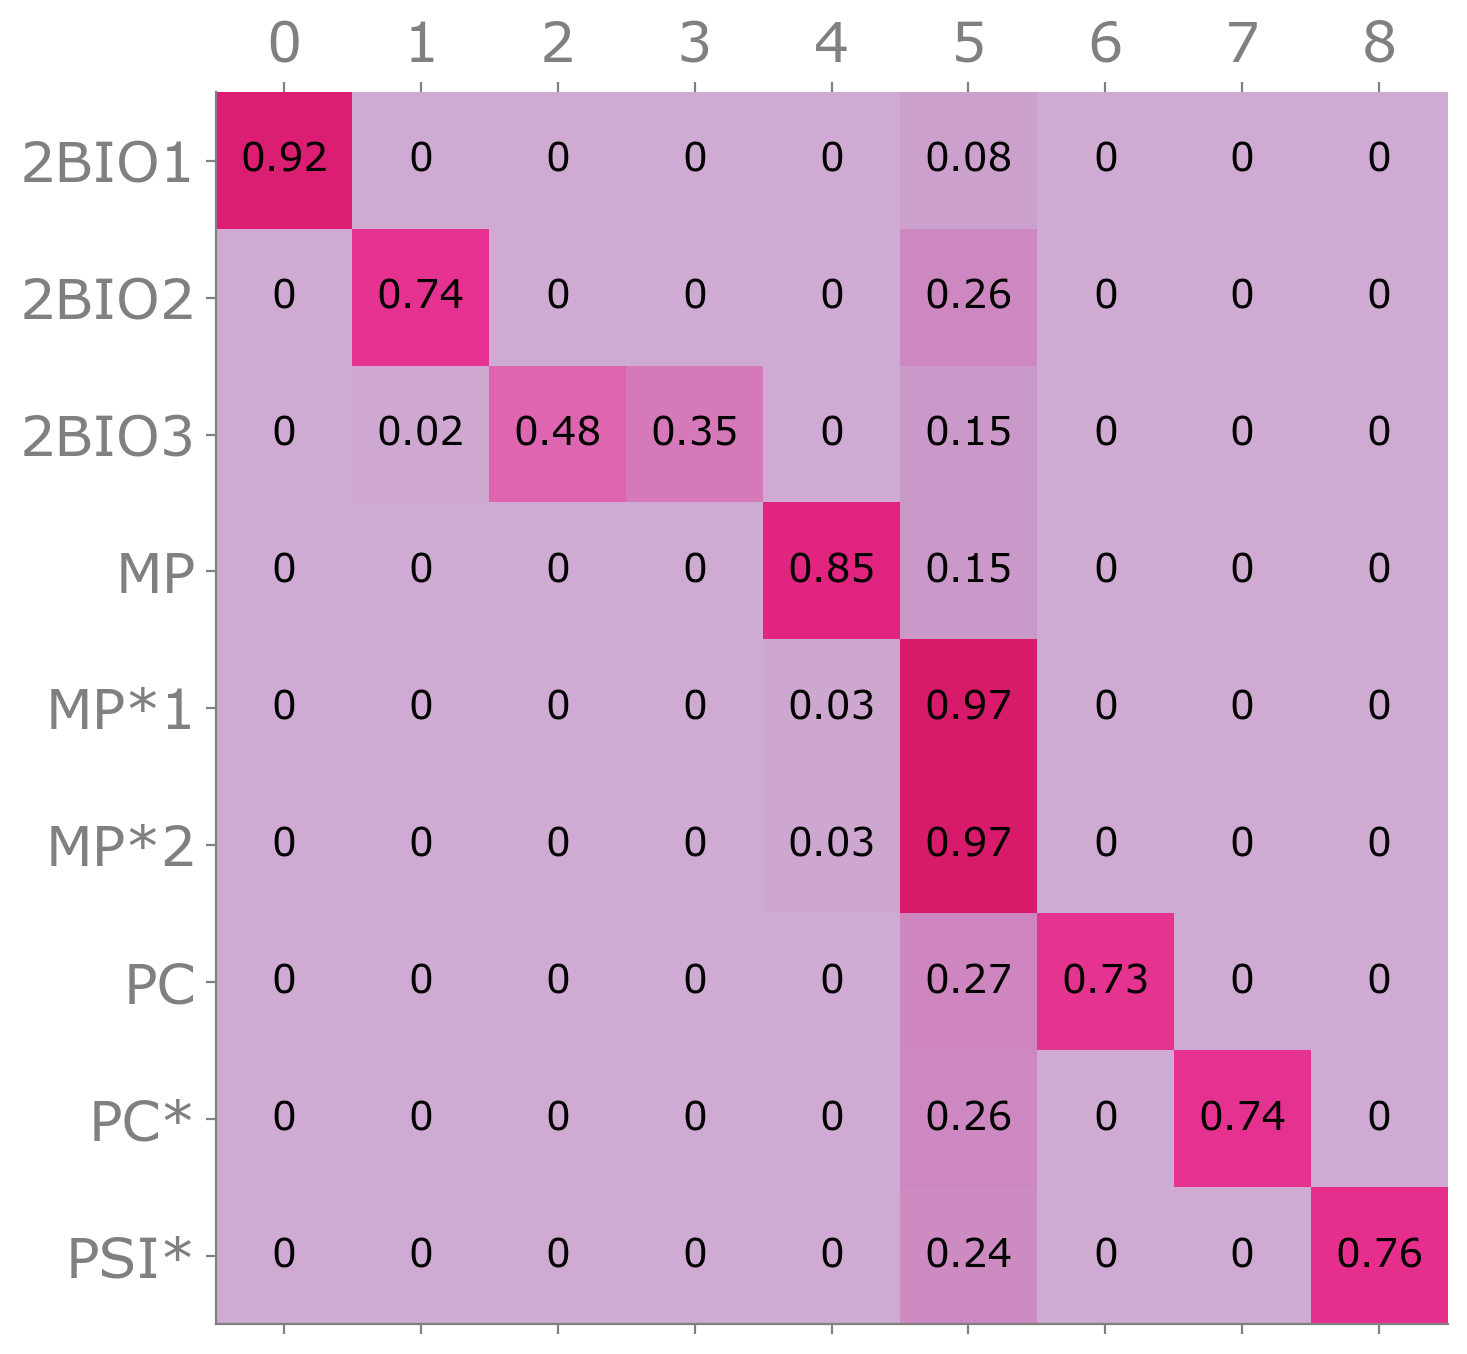

In [14]:
cm, df = visualMetaCM(reordered_partition, meta)
fig = plt.figure(figsize=(8, 8))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
# cmap = mpl.colormaps["seismic_r"]
cmap = mpl.colormaps["PuRd"]
cmap = truncate_colormap(cmap, 0.3, 0.7)
rowsum = np.sum(cm, axis=1)
rowsum = rowsum.reshape(-1, 1)
rowsum = np.repeat(rowsum, np.shape(cm)[1], axis=1)
norm_cm = np.round(cm / rowsum, 2)
print(cm)
ax.matshow(norm_cm, cmap=cmap, vmin=0, vmax=np.max(norm_cm))
for i in range(np.shape(cm)[0]):
    for j in range(np.shape(cm)[1]):
        c = norm_cm[i,j]
        ax.text(j, i, str(np.round(c, 3) if c != 0 else 0), va='center', ha='center', fontsize=14)
ax.set_xticks(np.arange(0, np.shape(cm)[1]), np.arange(0, np.shape(cm)[1]), fontsize=20)
ax.set_yticks(np.arange(0, np.shape(cm)[0]), meta_labels, fontsize=20)
print(ax.get_xticks())
save_path = "./_Figure/Hyper/" + "FigureHighCm.pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600)

In [43]:
def community_layout(graph, node_community, specific_scale=None):
    """生成社区布局，使得同一社区的节点靠近"""
    pos = {}
    # 每个社区分配一个中心
    num_communities = len(set(node_community.values()))
    angle_step = 2 * np.pi / num_communities
    community_centers = {
        i: (np.cos(i * angle_step), np.sin(i * angle_step))
        for i in range(num_communities)
    }

    # 为每个社区内的节点分配布局
    for community, center in community_centers.items():
        scale = specific_scale[community] if community in specific_scale else 0.2
        # 取出该社区的节点
        nodes = [n for n in graph if node_community[n] == community]
        # 使用 spring_layout 为社区内部布局
        subgraph = graph.subgraph(nodes)
        subgraph_pos = nx.spring_layout(subgraph, k=2, center=center, scale=0.2)
        pos.update(subgraph_pos)

    return pos

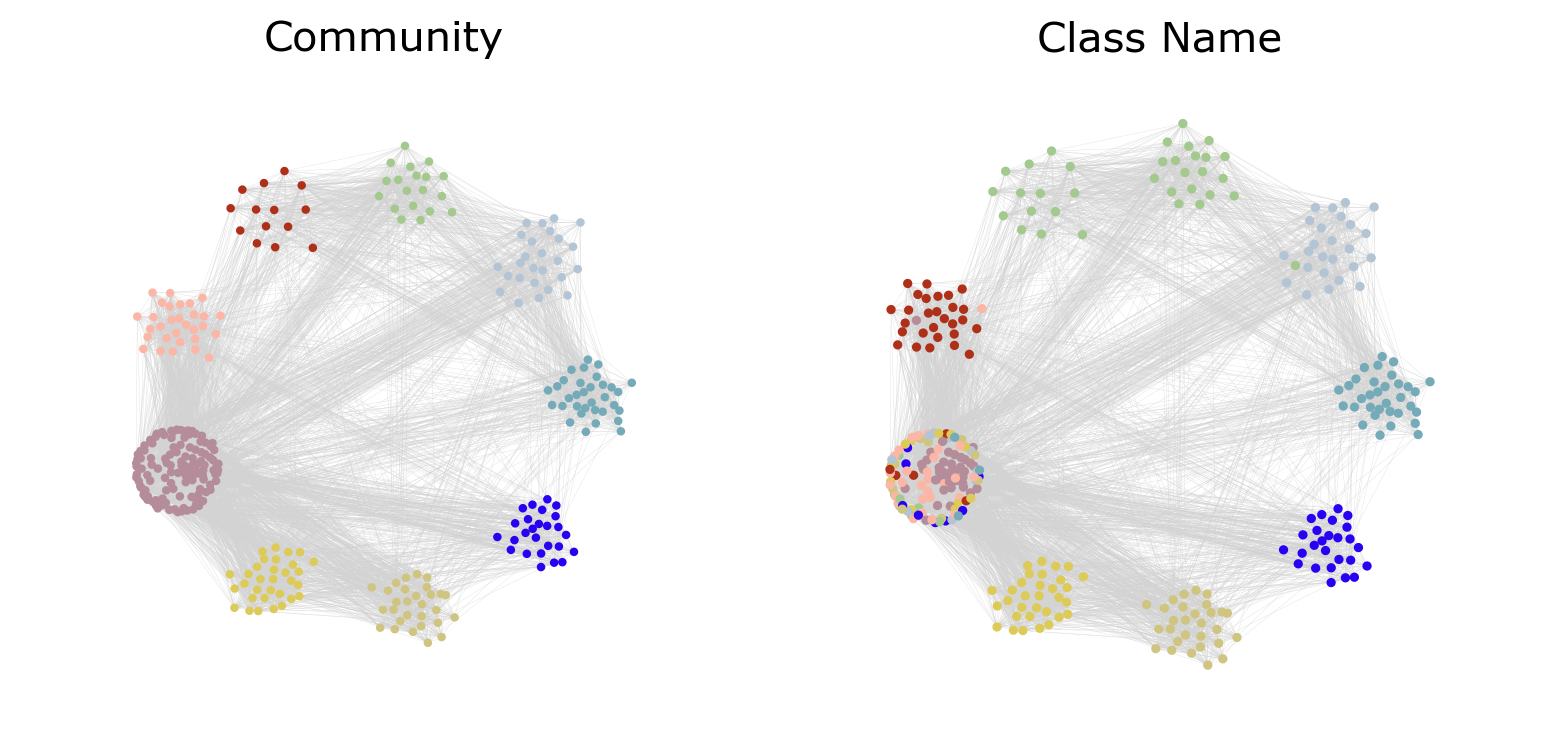

In [61]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
import matplotlib as mpl
import networkx as nx
fig = plt.figure(figsize=(8, 4))
widths = [4, 4]
heights = [4]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)

colors = ['#75AAB8', '#B3C4D4', '#A3C98E', '#AE3019', '#FCB6A5', '#B58C9A', '#DCCB59', '#CFC580', "#2900F2"]
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
### Color
n_bin = givenNumGroup
cmap = LinearSegmentedColormap.from_list("my_cmap", colors, N=n_bin)
color = cmap(np.linspace(0, 1, n_bin))
### Position
proj_graph = nx.from_scipy_sparse_array(hgx_hypergraph.adjacency_matrix())
node_community = {i:reordered_partition[i] for i in range(ehg.n)}
# pos = nx.spring_layout(proj_graph, k=1, iterations=100)
pos = community_layout(proj_graph, node_community, specific_scale={5: 18})
draw_communities(hypergraph=hgx_hypergraph, u=u_partition, col=color, ax=ax, pos=pos,
                 node_size=0.02, with_node_labels=False, scale=2, edge_width=0.1, wedge_width=0,
                 title='Community')
# ticks = n_bin * ((1/(2*(n_bin))) + np.arange(n_bin) * (1/(n_bin)))
# cbar = plt.colorbar(ScalarMappable(cmap=cmap, norm=plt.Normalize(0, n_bin)), ticks=ticks, label='Class', ax=ax)
# cbar.ax.set_yticklabels(meta_labels)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
### Color
n_bin = len(meta_labels)
cmap = LinearSegmentedColormap.from_list("my_cmap", colors, N=n_bin)
# cmap = mpl.colormaps['tab10']
color = cmap(np.linspace(0, 1, n_bin))
### Position
# proj_graph = nx.from_scipy_sparse_array(hgx_hypergraph.adjacency_matrix())
# node_community = {i:meta_labels.index(meta[i]) for i in range(ehg.n)}
# pos = nx.spring_layout(proj_graph, k=1, iterations=100)
# pos = community_layout(proj_graph, node_community)
draw_communities(hypergraph=hgx_hypergraph, u=u_meta, col=color, ax=ax, pos=pos,
                 node_size=0.02, with_node_labels=False, scale=3, edge_width=0.1, wedge_width=0,
                 title='Class Name')
save_path = f"./_Figure/Hyper/" + f"High_school_HyperBH.pdf"
# plt.tight_layout()
# plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.1, hspace=None)
plt.savefig(save_path, dpi=600)

[0.5 1.5 2.5 3.5 4.5 5.5 6.5 7.5 8.5]


C:\Users\24391\AppData\Local\Temp\ipykernel_15516\27659889.py:22: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


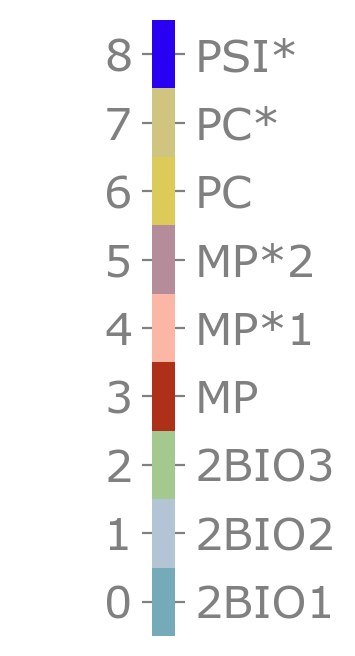

In [62]:
fig = plt.figure(figsize=(1, 4))
ax = fig.add_subplot()
ax.spines[['left', 'bottom']].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ticks = n_bin * ((1/(2*(n_bin))) + np.arange(n_bin) * (1/(n_bin)))
print(ticks)
cbar = plt.colorbar(ScalarMappable(cmap=cmap, norm=plt.Normalize(0, n_bin)), ticks=ticks, label='', ax=ax)
cbar.ax.set_yticklabels(list(range(n_bin)))
cbar.outline.set_visible(False)
cbar.ax.yaxis.set_ticks_position('left')
cbar.ax.yaxis.set_label_position('left')

cax = cbar.ax.twinx()
cax.spines[['left', 'bottom']].set_visible(False)
cax.set_xticks([])
cax.set_ylim(0, n_bin)
cax.set_yticks(ticks)
cax.set_yticklabels(meta_labels)

save_path = f"./_Figure/Hyper/" + f"High_school_HyperBH_Colorbar.pdf"
plt.tight_layout()
# plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.1, hspace=None)
plt.savefig(save_path, dpi=600, bbox_inches='tight')